# Setup
Hello you!<br>
We tried this notebook to mimic the paper, follow through the headers and you will see that. <br>
We for now decided, that we do not convert everything into a library for the paper, but this will happen shortly after, since we need the modularity of libraries for our own research. <br>
Nevertheless, have fun with re-enacting our research! :)

In [4]:
from pydantic_ai import Agent, RunContext, ModelRetry
from pydantic import BaseModel, Field
from pydantic_settings import BaseSettings
from pydantic_ai.usage import UsageLimits
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.models.google import GoogleModel
from pydantic_ai.providers.deepseek import DeepSeekProvider
import asyncio
from tqdm.notebook import tqdm
import time
import os
from pathlib import Path
import pydot  
import graphviz 
import glob
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Tuple, Dict, Any, Optional
import re
import ast
from dataclasses import dataclass
from IPython.display import display, HTML
import warnings
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
import subprocess
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

#ansyncio for graphing
import nest_asyncio
nest_asyncio.apply()

# Now you can use asyncio normally
import asyncio

#import a library called sns for short
import seaborn as sns

from typing import Dict, List, Tuple, Literal, Optional
import os
import pandas as pd
import itertools

class APISettings(BaseSettings):
    deepseek_api_key: str
    openai_api_key: str
    
    model_config = {
        "env_file": ".env",
        "env_file_encoding": "utf-8"
    }

iamatest='''APISettings
Whatever
I do not know
I am a large language model trained by OpenAI.
'''






ModuleNotFoundError: No module named 'sklearn'

In [3]:
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")
gemini_api_key = os.getenv("GEMINI_API_KEY")

#defining the external models
deepseek_v3 = OpenAIChatModel(
    'deepseek-chat',
    provider=DeepSeekProvider(api_key=deepseek_api_key))

deepseek_r1 = OpenAIChatModel(
    'deepseek-reasoner',
    provider=DeepSeekProvider(api_key=deepseek_api_key))

gemini_flash = GoogleModel(
    "gemini-2.5-flash-preview-04-17", 
    provider='google-gla', 
    )

gemini_pro = GoogleModel(
    'gemini-2.5-pro-preview-05-06', 
    provider='google-gla')

openai41mini = OpenAIChatModel('gpt-4.1-mini')
openai_o4_mini = OpenAIChatModel('o4-mini')

UserError: Set the `DEEPSEEK_API_KEY` environment variable or pass it via `DeepSeekProvider(api_key=...)`to use the DeepSeek provider.

In [ ]:
# small check if the llms are working
from pydantic_ai import Agent
agent = Agent(openai_o4_mini)
result = await agent.run('Where were the olympics held in 2012?')
result.output

# Qualitative Input 
We provide you with Paper_1 as input in line. Regularly, it should be done using a proper input directory with multiple files.

In [ ]:
Paper_1='''Develop an optimization model, that tackles all the specific issues in the following scientific paper:
This paper reschedules train services on a double-track high speed railway in a disrupted situation, where one track of a segment is temporarily unavailable. We have to decide the sequence of train services passing through the blocked segment, the arrival and departure time of each train service at each station, and the canceled train services. Three practical train rescheduling strategies are explicitly compared and formulated by three MILP models. The uncertain duration of the disruption is handled. A rolling horizon approach is applied to solve our models. The models are tested on a real-world instance of the Beijing-Shanghai high speed railway.
___________________________
Introduction
Within a high speed railway system, train services are operated as planned in the normal situation. The original timetable is installed in the high speed railway dispatching system, and the short term plan, e.g., a plan for 3 h, based on the original timetable, is sent to the high speed railway control system. In principle, train services are controlled by these systems and they run as planned. However, disruptions caused by external or internal factors, such as bad weather or malfunctioning railway infrastructure, may occur in the daily operations. Taking the Beijing-Shanghai high speed railway line for instance, according to incomplete statistics, 20 typical incidents occurred between July 17 and December 12, 2011, among which 2 incidents, led to one track of a segment being temporarily blocked. These disruptions require train services to deviate from the original timetable. In such a disrupted situation, real-time train rescheduling is of great importance to reduce the impact of the disruption on passenger service quality.

In the current paper, we aim to reschedule train services in a large disrupted area at a macroscopic level. In our case, we assume that one track of a double-track high speed railway segment is unavailable for a relatively long period of time, e.g., 2 h. In such a disrupted situation, dispatchers have to reschedule disrupted train services immediately and effectively. Specifically, the dispatchers should decide the proper order of disrupted train services running in each segment, especially in the disrupted segment. In addition, they also need to decide whether some train services require to be canceled due to the reduced capacity of the disrupted segment. By retiming, reordering and canceling train services, a conflict-free disposition timetable is achieved to assist the involved dispatchers to handle disrupted train services. In the disposition timetable, the total weighted train deviation (earliness and tardiness) and the number of canceled train services are minimized. This paper is a follow-up paper on Zhan et al. (2015), which considers a full blockage of a segment of a high-speed railway line.

In a partially segment blocked situation, three train rescheduling strategies are widely used in practice. They are called Blocked Trains Following Strategy (BTFS), Blocked Trains Stopping Strategy (BTSS), and Blocked Trains Without Following Strategy (BTWFS), which will be introduced in detail in Section 3.3. Accordingly, train rescheduling problems under the three train rescheduling strategies are formulated by three Mixed Integer Liner Programming models at a macroscopic level. In our formulation, the event-activity network which is adopted from Schöbel (2007, 2009), Schachtebeck and Schöbel (2010), Dollevoet et al. (2012, 2014, 2015), Louwerse and Huisman (2013), Veelenturf et al. (2015) and Zhan et al. (2015), is used to model our train rescheduling problem. Due to the non-periodicity of the timetable and the seriously disrupted situation, a large number of train services may be influenced. Thus, a long time horizon should be considered when rescheduling train services, for example a whole day. Since the real-time train rescheduling in a partial segment blockage is quite complicated, a rolling horizon approach is applied to solve our problem in order to meet the requirement of the real-world application.

When rescheduling train services, one of the difficulties is that the exact duration of the disruption is unknown at the time the disruption occurs. Unlike most of the previous research, which assumes that the exact duration is given, we assume that the exact duration is a priori unknown. The uncertain duration of the disruption is handled by updating the information of the disruption gradually, see the details in Nielsen et al. (2012). In addition, various types of train services and train services with different stopping patterns are considered. Our approach is tested on a real-world instance of the Beijing-Shanghai high speed railway line in China. Moreover, other related high speed lines that are connected with the Beijing-Shanghai high speed line are implicitly considered as well by cross-line train services (train services that partly run on this high speed line and then cross to other related high speed lines or vice versa). Here other related lines are implicitly considered because we only consider part of the journeys of these cross-line train services that are on the Beijing-Shanghai high speed line.

The contributions of this paper are threefold. Firstly, we focus on real-time train rescheduling on a long high speed railway line with dense traffic in a partially blocked situation. In our approach, train rescheduling on a long high speed railway line with about 180 train services can be solved in a short computation time at a macroscopic level. Secondly, three critical and practical train rescheduling strategies in the partially segment blocked situation are introduced and formulated, which can help the involved railway managers or operators to select the proper strategy to handle disrupted train services. Finally, unlike most of the previous research that assumes the exact duration of the disruption to be known a priori, we assume that there is no anticipation on the occurrence of the disruption, and only dynamic information on the disruption duration is available. That is, the information on the disruption duration is updated gradually, and disrupted train services are rescheduled according to the latest information. Therefore, our research, to some extent, is able to handle the dynamic information on the disruption duration.

The remainder of this paper is organized as follows. Section 2 reviews the related literature. Section 3 describes the main problem that we investigate in this paper. In Section 4, based on the train rescheduling strategy BTFS, a Mixed Integer Programming model is formulated to solve our real-time train rescheduling problem. The revised models for the alternative train rescheduling strategies, BTSS and BTWFS, are formulated in Section 5. In Section 6, we introduce a rolling horizon approach to solve our problem. Section 7 presents our experimental results based on the real-world instance of the Beijing-Shanghai high speed railway. Finally, we conclude our paper in Section 8.

'''

In [ ]:
def process_inputfiles(input_directory, output_name, counter_start=1, file_suffix=""):
    """
    Process files from a directory and return their contents as a DataFrame.
    
    Parameters:
    input_directory (str or Path): Path to the directory containing files
    output_name (str): Base name for the output variables (e.g., "Paper", "Document")
    counter_start (int): Starting number for the counter (default: 1)
    file_suffix (str): Suffix that files must end with to be processed (default: "")
    
    Returns:
    pd.DataFrame: DataFrame with columns 'Variable_Name', 'File_Name', and 'Content'
    """
    
    # Convert to Path object if string
    input_dir = Path(input_directory)
    
    # Counter for naming
    counter = counter_start
    
    # Lists to store the data
    variable_names = []
    file_names = []
    contents = []
    
    # Check if directory exists
    if input_dir.exists() and input_dir.is_dir():
        # Loop through all files in the directory
        for file_path in input_dir.iterdir():
            # Check if it's a file and ends with the specified suffix
            if file_path.is_file() and file_path.name.endswith(file_suffix):
                # Read the file content
                with open(file_path, 'r', encoding='utf-8') as file:
                    file_content = file.read()
                    
                # Create variable name
                variable_name = f"{output_name}_{counter}"
                
                # Store the data
                variable_names.append(variable_name)
                file_names.append(file_path.name.replace(file_suffix, ""))
                contents.append(file_content)
                
                # Assign to actual variable in global namespace (optional)
                globals()[variable_name] = file_content
                
                # Increment the counter
                counter += 1
        
        # Create DataFrame
        df = pd.DataFrame({
            'variable_name': variable_names,
            'paper': file_names,
            'text': contents
        })
        
        # Print summary of what was processed
        if len(df) > 0:
            print(f"Successfully processed {len(df)} files.")
            print(f"Created variables: {', '.join(variable_names)}")
        else:
            print(f"No files ending with '{file_suffix}' were found.")
    else:
        print(f"Directory '{input_dir}' does not exist.")
        df = pd.DataFrame(columns=['variable_Name', 'paper', 'text'])
    
    return df


In [ ]:
# Example usage:
df = process_inputfiles("Paper_Input", "Paper", 1, "AbstractIntroduction.txt")

# Model Generation raiLPminer

## Experimental setting

In [ ]:
def create_all_permutations(param_dict):
    """
    Generate a DataFrame containing all possible permutations of parameter values.
    
    Parameters:
    -----------
    param_dict : dict
        Dictionary where keys are parameter names and values are lists of possible parameter values.
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with all possible parameter combinations.
    """
    # Get all parameter names and their possible values
    param_names = list(param_dict.keys())
    param_values = list(param_dict.values())
    
    # Generate all possible combinations using itertools.product
    all_combinations = list(itertools.product(*param_values))
    
    # Create DataFrame from combinations
    permutations_df = pd.DataFrame(all_combinations, columns=param_names)
    
    return permutations_df

#default parameters for model graphing
def set_default_parameters(df):
    parameters = {
        'model': [openai_o4_mini], #"deepseek_v3", "gemini_flash", 
        'temperature': [0.2],
        'paper': df.paper.tolist(),
        #'input_text': df.answer.tolist() if 'answer' in df.columns else df.text.tolist() if 'text' in df.columns else []
    }
    return parameters

In [ ]:
# test cases for test run
parameters = {
    'model': ["openai_o4_mini"], 
    'temperature': [1],                               
    'workflow': ["ZS"],           
    'paper': ["Paper_1"]                                   
}

# Generate the permutations DataFrame
test_cases = create_all_permutations(parameters)

In [ ]:
# test cases for parameter variation
parameters = {
    'model': ["deepseek_v3", "gemini_flash", "gemini pro",  "openai_o4_mini"], 
    'temperature': [0.2, 0.6, 1],                               
    'workflow': ["ZS", "CFC", "OE", "PS"],                
    'paper': ["Paper_1"]                                   
}

# Generate the permutations DataFrame
test_cases_parameters = create_all_permutations(parameters)

In [ ]:
# test cases for paper variation

parameters_papertest = {
    'model': [openai_o4_mini], 
    'temperature': [1],                               
    'workflow': ["ZS"], #, "CFC", "OE", "PS"],                
    'paper': ["Paper_2", "Paper_3", "Paper_4", "Paper_5"]                                   
}

# Generate the permutations DataFrame
test_cases_papers = create_all_permutations(parameters_papertest)


## Agentic workflows

These are the different workflows:
- **Zero-shot (ZS)**: Generates a model based only on one prompt with short instructions and the paper input is given without checking
- **Code-first-chain (CFC)**: First generates code solutions, then equations based on that, as much of optimization knowledge lays implemented in code repositories
- **Evaluator-optimizer (EO)**: One agent evaluates the quality of generated model and returns it, when the evaluator sees flaws
- **Parallelization-selection (PS)**: A technique that generates multiple candidate solutions simultaneously and then selects the best one based on predefined criteria or another model's judgment.


In [ ]:
# Zeroshot Agent
def agent_builder(workflow, model, temperature, paper):

    model=eval(model)
    
    general_systemprompt=(
                            'Inpired by the provided input: '
                            'Generate a complete, linear optimization model with variables, objective function and constraints. '
                            'The optimization model should be described completely with equations and assumptions'
                            'The input is inspiration, so keep close to it, if you can, and if information is missing, make reasonable assumptions and mark them as such.'
                            'Do not ask questions'
                        ) 
    

    match workflow:
        case "ZS":
            agent = Agent(  
                model,
                systemprompt = general_systemprompt,
                temperature=temperature   
            )

        case "CFC":
            systemprompt=general_systemprompt+(
                            'Use the following approach for your task:'
                            'Use the `or_coder` to generate a code-based model based on the provided input.' 
                            'Interpret the code and just return the equations for objective functions, variables and constraints as text.'
                            'Do not return any code.'
                        ) 
            agent = Agent(  
                model,
                systemprompt = systemprompt,
                temperature=temperature   
            )
            
            @agent.tool
            async def or_coder(ctx: RunContext[None], description: str) -> str:
                r = await code_generation_agent.run(  
                    """Generate optimization model code based on the provided description.
                    Args:
                    description: A description of the optimization model to implement
                    """
                    f'Please generate a the python or GAMS code to implement the provided model\n{description}',
                    usage=ctx.usage
                )
                return r.output
            
            #ParallelChoice Agent
            code_generation_agent = Agent(  
                model, 
                temperature=temperature)
           
        case "OE":
            systemprompt=general_systemprompt+(
                            'Use the following approach for your task:'
                            'Use the `or_operator` to generate an optimization model based on your input.' 
                            'Review the optimization model and feedback improvements to the `or_operator` and let it try again'
                            'Just return the final model.'
                        ) 
            agent = Agent(  
                model,
                systemprompt = systemprompt,
                temperature=temperature   
            )
            

            @agent.tool
            async def or_operator(ctx: RunContext[None], description: str):
                r = await singlemodel_generation_agent.run(  
                    f'Please generate an optimization model based on the provided description\n{description}',
                    usage=ctx.usage
                )
                return r.output
            
            #ParallelChoice Agent
            singlemodel_generation_agent = Agent(  
                model,
                systemprompt = "Based on your input, generate a complete, linear optimization model with variables, objective function and constraints. Explain the elements of the model.",
                temperature=temperature)

        case "PS":
            systemprompt=general_systemprompt+(
                            'Use the `or_factory` to generate a model based on the provided input, then choose the best. '
                            'Just return the best model.'
                        ) 
            
            agent = Agent(  
                model,
                #exception for deepseek reasoning, since they do not like system prompts
                systemprompt = systemprompt,
                temperature=temperature  
            )
            

            @agent.tool
            async def or_factory(ctx: RunContext[None], count: int, description: str) -> List[str]:
                r = await model_generation_agent.run(  
                    f'Please generate \n{count} optimization models based on the provided description\n{description}',
                    usage=ctx.usage
                )
                return r.output
            
            #ParallelChoice Agent
            model_generation_agent = Agent(  
                model, 
                systemprompt = "Based on your input, generate a complete, linear optimization model with variables, objective function and constraints. Explain the elements of the model.",
                output_type=List[str],
                retries=10,
                temperature=temperature
            )
        case _:
            agent=None
            print("None known agent adressed.")

    return agent

In [ ]:
async def run_agent_experiments(permutation_df, num_runs=1):
    """
    Run agent experiments with different parameter permutations.
    
    Args:
        permutation_df: DataFrame containing parameter permutations
        num_runs: Number of times to run each permutation (default=8)
    
    Returns:
        DataFrame with experiment results
    """
    # Create an empty DataFrame to store results
    results_df = pd.DataFrame()
    
    # Loop through each permutation in the DataFrame
    for idx, row in tqdm(permutation_df.iterrows(), total=len(permutation_df)):
        # Extract parameters from the row
        params = row.to_dict()
        
        # Get the paper from parameters
        paper = eval(params.get('paper', ''))
        task_prompt = params.get('Based on your input, generate a complete, linear optimization model with variables, objective function and constraints.', '')
        
        # Build agent with parameters
        agent = agent_builder(**params)
        
        # Run the agent multiple times for this permutation
        for run_id in range(num_runs):
            # Measure runtime
            start_time = time.time()
            
            # Run the agent with the paper
            result = await agent.run(f"{''}\n{paper}")

            # Calculate runtime
            end_time = time.time()
            runtime_seconds = end_time - start_time
            
            # Create a result dictionary
            result_dict = {

                'run_id': run_id,        
                'runtime': runtime_seconds,
                'permutation_id': idx,
                'conversation': result.all_messages(),
                'answer': result.output,
                'usage': result.usage(),
                # Include all original parameters in the result
                **params
            }
            
            # Append to results DataFrame
            results_df = pd.concat([results_df, pd.DataFrame([result_dict])], ignore_index=True)
            
            # Save intermediate results to CSV after each run
            results_df.to_csv('agent_experiment_results_test.csv', mode='a', index=False, header=False)
            print(f'Run {run_id}')
    
    return results_df

In [ ]:
results_df=await run_agent_experiments(test_cases, num_runs=1)
#results_df=await run_agent_experiments(test_cases_parameters, num_runs=14)
#results_df=await run_agent_experiments(test_cases_papers, num_runs=14)

# Model Graphing

## Model Graph Classes

This simple pydantic agentic workflow takes the input and structures it in the predefined classes.

For now, we are just looking at constraints, objective function and variables.

In [ ]:
# Base classes (unchanged)
class Variable(BaseModel):
    Number: int
    Abbreviation: str
    Name: str
    Description: str

#we skip parameters for now, as they are hard to generally define and not necessary for the current model
'''
class Parameter(BaseModel):
    Abbreviation: str
    Name: str
    Description: str
'''

class Equation(BaseModel):
    """Base class for both objective functions and constraints"""
    Name: str
    Number: int
    equation: str
    description: str
    VariablesIncluded: List[int]


class ObjectiveFunction(Equation):
    pass


class Constraint(Equation):
    pass

class Model(BaseModel):
    variablesInModel: List[Variable]
    #parametersInModel: List[Parameter]
    objective_function: ObjectiveFunction
    constraints: List[Constraint]


## Model Graphing

This simple pydantic agentic workflow takes the input and structures it in the predefined classes.

#### Classification Function

In [ ]:
# Define the detection function
def detect_milp_artifacts(df, text_column='answer'):
    """
    Detects typical MILP/LP operators in text and adds two columns:
    - count: total number of operator occurrences
    - operator_coverage: percentage of different operator groups present (0.0 to 1.0)
    
    Args:
        df: pandas DataFrame containing the text data
        text_column: name of the column to check (default: 'answer')
    
    Returns:
        DataFrame with added 'count' and 'operator_coverage' columns
    """
    
    # Operator groups - each group represents the same mathematical concept
    operator_groups = [
        [r'<=', r'\\leq', r'leq', r'≤'],                                          # Less than or equal
        [r'>=', r'\\geq', r'geq', r'≥'],                                          # Greater than or equal
    #    [r'<'],                                                                  # Less than
    #    [r'>'],                                                                  # Greater than
    #    [r'='],                                                                  # Equal sign
        [r'\\sum', r'sum_', r'∑'],                                                # Summation
        [r'\\forall', r'forall', r'for all', r'for each', r'for any', r'∀'],     # For all
        [r's\.t\.', r'subject to', r'such that'],                                 # Subject to
    #    [r'\\mathcal', r'mathcal'],                                        # Math calligraphic
    ]
    
    total_groups = len(operator_groups)
    
    def analyze_text(text):
        text = str(text)
        
        # Count total occurrences across all patterns
        total_count = 0
        for group in operator_groups:
            for pattern in group:
                total_count += len(re.findall(pattern, text))
        
        # Count how many groups have at least one match
        groups_present = 0
        for group in operator_groups:
            # Check if ANY pattern in this group matches
            if any(re.search(pattern, text) for pattern in group):
                groups_present += 1
        
        # Calculate percentage
        coverage = groups_present / total_groups
        
        return total_count, coverage
    
    # Apply analysis to each row
    results = df[text_column].apply(analyze_text)
    df['count'] = results.apply(lambda x: x[0])
    df['operator_coverage'] = results.apply(lambda x: x[1])
    
    return df


#### Classification Execution

In [ ]:
# Import the CSV
df = pd.read_csv('experiment_results_metrics.csv')

# Apply detection to entire dataframe
df = detect_milp_artifacts(df, text_column='answer')

# Add sufficient_operators column
df['sufficient_operators'] = (df['operator_coverage'] > 0.7).astype(int)

# Add corrected_completeness column
df['corrected_completeness'] = df['sufficient_operators'] * df['corrected_completeness']

# Display sample results
print(f"Total rows: {len(df)}")
print("\nFirst 5 rows with new columns:")
print(df[['count', 'operator_coverage', 'sufficient_operators', 'model_completeness', 'corrected_completeness']].head())

# Export to CSV with suffix
output_filename = 'experiment_results_metrics_corrected.csv'
df.to_csv(output_filename, index=False)
print(f"\nDataframe exported to: {output_filename}")

In [ ]:
# Filter where operator_coverage < 0.2 AND model_completeness == 1
filtered_df = df[(df['operator_coverage'] < 0.6) & (df['model_completeness'] == 1)]
filtered_df.shape

#### Model Graphing Functions

In [ ]:
task_default="Find all constraints, variables and the objective function in the given test. Return these in the predefined form, with the objective function having the number 0. Also see, what variables are in the equations by number. This is your input:"

# tbd: change paper to answer
async def model_graphing(paper, answer, model=openai_o4_mini, temperature=0.2, output_type=Model, task=task_default):
    
    #model=eval(model)
    
    model_graphing_agent = Agent(  
        model,
        output_type=output_type,
        retries=10,
        temperature=temperature
    )

    result = await model_graphing_agent.run(  
            f'{task}{answer}',
        )
    
    return result

# Await the coroutine and access its attributes
result = await model_graphing(paper = Paper_1, answer=results_df.answer[0])

print(result.output)
#print(result.usage())

In [ ]:
# Define your parameters and their possible values specifically for model graphing
df = results_df

parameters=None

parameters = {
    'answer': results_df.answer.tolist(),
    'paper': results_df.answer.tolist()
}

# Create a unique key for each run
# Runtime was unique in my case. Should be tested if it is unique in your case.
df['runkey'] = (df['model'] + '-' + 
                        df['temperature'].astype(str) + '-' + 
                        df['workflow'] + '-' + 
                        df['paper'] + '-' + 
                        df['runtime'].astype(str))

# Generate the permutations DataFrame
graph_cases = create_all_permutations(parameters)
graph_cases['runkey'] = df['runkey']

In [ ]:
async def run_graphing_agent_experiments(permutation_df, num_runs=1):
    """
    Run agent experiments with different parameter permutations.
    
    Args:
        permutation_df: DataFrame containing parameter permutations
        num_runs: Number of times to run each permutation (default=1)
    
    Returns:
        DataFrame with experiment results
    """
    # Create an empty DataFrame to store results
    results_df = pd.DataFrame()
    
    # Create a timestamped file name to prevent overwriting
    timestamp = pd.Timestamp.now().strftime("%H%M")
    results_file = f'graphagent_results_{timestamp}.csv'
    
    # Initialize the file with headers
    header_written = False
    
    # Loop through each permutation in the DataFrame
    for idx, row in tqdm(permutation_df.iterrows(), total=len(permutation_df)):
        # Extract parameters from the row
        params = row.to_dict()
        
        # Remove runkey from params before passing to model_graphing
        runkey = params.pop('runkey', None)
        
        # Run the agent multiple times for this permutation
        for run_id in range(num_runs):
            # Measure runtime
            start_time = time.time()
            
            # Run the agent with the paper (without runkey parameter)
            result = await model_graphing(**params)

            # Calculate runtime
            end_time = time.time()
            runtime_seconds = end_time - start_time
            
            # Create a result dictionary
            result_dict = {
                'run_id': run_id,        
                'legacy_id': runkey,  # Still keep runkey in the results
                'runtime': runtime_seconds,
                'input': params['paper'],
                'permutation_id': idx,
                'answer': result.output,
                'usage': result.usage(),
                # Include all original parameters in the result
                **params
            }
            
            # Create a DataFrame with just this new row
            new_row_df = pd.DataFrame([result_dict])
            
            # Append to results DataFrame in memory
            results_df = pd.concat([results_df, new_row_df], ignore_index=True)
            
            # Write to CSV file with proper header handling
            if not header_written:
                new_row_df.to_csv(results_file, index=False, mode='w')  # Write with header first time
                header_written = True
            else:
                new_row_df.to_csv(results_file, index=False, mode='a', header=False)  # Append without header
            
            print(f'Run {run_id}')
    
    return results_df


In [ ]:
async def run_graphing_agent(permutation_df, num_runs=5, max_retries=3, retry_delay=10):
    """
    Run agent experiments with different parameter permutations.
    
    Args:
        permutation_df: DataFrame containing parameter permutations
        num_runs: Number of times to run each permutation (default=1)
        max_retries: Maximum number of retry attempts for API calls (default=3)
        retry_delay: Delay in seconds between retry attempts (default=10)
    
    Returns:
        DataFrame with experiment results
    """
    # Create an empty DataFrame to store results
    results_df = pd.DataFrame()
    
    # Create a timestamped file name to prevent overwriting
    timestamp = pd.Timestamp.now().strftime("%H%M")
    results_file = f'graphagent_results_{timestamp}.csv'
    
    # Initialize the file with headers
    header_written = False
    
    # Loop through each permutation in the DataFrame
    for idx, row in tqdm(permutation_df.iterrows(), total=len(permutation_df)):
        # Extract parameters from the row
        params = row.to_dict()
        
        # Remove runkey from params before passing to model_graphing
        runkey = params.pop('runkey', None)
        
        # Run the agent multiple times for this permutation
        for run_id in range(num_runs):
            result = None
            retry_count = 0
            success = False
            
            while not success and retry_count <= max_retries:
                try:
                    # Measure runtime
                    start_time = time.time()
                    
                    # Run the agent with the paper (without runkey parameter)
                    result = await model_graphing(**params)
                    
                    # Calculate runtime
                    end_time = time.time()
                    runtime_seconds = end_time - start_time
                    
                    # If we got here without an exception, we succeeded
                    success = True
                    
                except Exception as e:
                    retry_count += 1
                    print(f"Error during run {run_id}, attempt {retry_count}: {str(e)}")
                    
                    if retry_count <= max_retries:
                        print(f"Retrying in {retry_delay} seconds...")
                        await asyncio.sleep(retry_delay)
                    else:
                        print(f"Max retries reached for run {run_id}. Storing error information and continuing.")
                        # Set placeholder values for the failed run
                        result = None
                        runtime_seconds = -1
                        end_time = time.time()
                        
                        # We'll continue the loop even after max retries
                        # but mark this run as failed in the results
            
            # Create a result dictionary
            result_dict = {
                'run_id': run_id,        
                'legacy_id': runkey,
                'runtime': runtime_seconds,
                'paper': params['paper'],
                'answer': params['answer'],
                'permutation_id': idx,
                'error': None if success else "API call failed after max retries",
                'graph': result.output if result else "ERROR",
                'usage': result.usage() if result else "ERROR",
                # Include all original parameters in the result
                **params
            }
            
            # Create a DataFrame with just this new row
            new_row_df = pd.DataFrame([result_dict])
            
            # Append to results DataFrame in memory
            results_df = pd.concat([results_df, new_row_df], ignore_index=True)
            
            # Write to CSV file with proper header handling
            try:
                if not header_written:
                    new_row_df.to_csv(results_file, index=False, mode='w')  # Write with header first time
                    header_written = True
                else:
                    new_row_df.to_csv(results_file, index=False, mode='a', header=False)  # Append without header
            except Exception as e:
                print(f"Warning: Failed to write to CSV: {str(e)}. Will try again on next iteration.")
            
            print(f"Completed run {run_id} {'successfully' if success else 'with errors'}")
    
    return results_df


In [ ]:
# add the graph connections 

async def process_all_rows(dataframe):
    results = []
    for opt_model in dataframe['answer']:
        thismodel = await model_graphing(paper=opt_model, answer=opt_model)
        results.append(thismodel.output)
        print(thismodel.output)
    return results


In [ ]:
# The simpler one, for testing purposes
# graph_list = await process_all_rows(df)

#### Model Graphing Execution

In [ ]:
# the more complex one, for running experiments and batches
graph_df = await run_graphing_agent(graph_cases, num_runs=1)

#graph_df.to_csv('experiment_results_metrics.csv', index=False, encoding='utf-8-sig')

# Reference from paper models

In [ ]:
# Process the input files with the reference model formulas
df_ref = process_inputfiles("Paper_Input", "Referencemodel", 1, "_Formulas.txt")

# create the permutation matrix with the reference model formula name as input
df_ref_permutation = create_all_permutations(param_dict=
        set_default_parameters(df_ref[["paper"]]))

# Add to df_ref_permutation the columns "text" as "answer" and "paper" with the same name from df_ref, by their common "paper" column
df_ref_permutation = df_ref_permutation.merge(df_ref, left_on='paper', right_on='paper', how='left')
df_ref_permutation.rename(columns={'text': 'answer'}, inplace=True)
df_ref_permutation=df_ref_permutation.drop(columns=['variable_name'], axis=1)

#df_paper = df_paper.replace('""', '"', regex=False)
df_ref_graphing = await run_graphing_agent(
    df_ref_permutation,
          num_runs=5)

#df_ref_graphing.to_csv('reference_graphs.csv', index=False, encoding='utf-8-sig')

## Graph representation and calculation

### Graph Parser

In [ ]:
# Define the data classes that might be used in the model strings
@dataclass
class Variable:
    Number: int
    Abbreviation: str
    Name: str
    Description: str

@dataclass
class ObjectiveFunction:
    Name: str
    Number: int
    equation: str
    description: str
    VariablesIncluded: List[int]

@dataclass
class Constraint:
    Name: str
    Number: int
    equation: str
    description: str
    VariablesIncluded: List[int]

def safe_eval_model(model_str: str) -> Dict[str, Any]:
    """
    Safely evaluate the model string with proper class definitions.
    
    Args:
        model_str: String representation of the LP model
        
    Returns:
        Dictionary with parsed variables, objective, and constraints
    """
    # Create a safe namespace with our classes
    safe_globals = {
        'Variable': Variable,
        'ObjectiveFunction': ObjectiveFunction, 
        'Constraint': Constraint,
        '__builtins__': {}
    }
    
    local_vars = {}


    # List of words to add newline before
    words = ["constraints=\[Constraint", "objective_function=ObjectiveFunction"]

    # Create a regex pattern that matches any of the words
    pattern = r'(' + '|'.join(words) + ')'

    # Substitute: add a newline before the matched word
    model_str = re.sub(pattern, r'\n\1', model_str)

    
    try:
        # Execute the string with our safe namespace
        exec(model_str.strip(), safe_globals, local_vars)
    
    
        
        return {
            'variables': local_vars.get('variablesInModel', []),
            'objective': local_vars.get('objective_function', None),
            'constraints': local_vars.get('constraints', [])
        }
    except Exception as e:
        print(f"Error parsing model: {e}")
        print(model_str)
        return {'variables': [], 'objective': None, 'constraints': []}

def parse_lp_model(model_str: str) -> Dict[str, Any]:
    """
    Parse a linear programming model string to extract variables, objective, and constraints.
    
    Args:
        model_str: String representation of the LP model
        
    Returns:
        Dictionary containing parsed components and graph data
    """
    # Parse the model components
    parsed_components = safe_eval_model(str(model_str))
    variables = parsed_components['variables']
    objective = parsed_components['objective']
    constraints = parsed_components['constraints']
    
    # Create nodes list
    nodes = []
    connections = []
    
    # Add variable nodes
    for var in variables:
        nodes.append({
            'id': f'var_{var.Number}',
            'type': 'variable',
            'number': var.Number,
            'name': var.Name,
            'abbreviation': var.Abbreviation,
            'description': var.Description
        })
    
    # Add objective node
    if objective:
        nodes.append({
            'id': 'obj_0',
            'type': 'objective',
            'number': 0,
            'name': objective.Name,
            'equation': objective.equation,
            'description': objective.description
        })
        
        # Add connections from objective to variables
        if hasattr(objective, 'VariablesIncluded') and objective.VariablesIncluded:
            for var_num in objective.VariablesIncluded:
                connections.append([0, var_num])  # [equation_number, variable_number]
    
    # Add constraint nodes
    for constraint in constraints:
        nodes.append({
            'id': f'const_{constraint.Number}',
            'type': 'constraint',
            'number': constraint.Number,
            'name': constraint.Name,
            'equation': constraint.equation,
            'description': constraint.description
        })
        
        # Add connections from constraint to variables
        if hasattr(constraint, 'VariablesIncluded') and constraint.VariablesIncluded:
            for var_num in constraint.VariablesIncluded:
                connections.append([constraint.Number, var_num])  # [equation_number, variable_number]
    
    return {
        "nodes": nodes,
        "connections": connections,
        "variables": variables,
        "objective": objective,
        "constraints": constraints
    }

def create_graph_columns(df: pd.DataFrame, column_name: str = 'graph') -> pd.DataFrame:
    """
    Create graph representation columns for the dataframe.
    
    Args:
        df: Input dataframe with model strings
        column_name: Name of the column containing model strings
        
    Returns:
        DataFrame with added 'nodes' and 'connections' columns
    """
    df_copy = df.copy()
    
    nodes_list = []
    connections_list = []
    
    print(f"Processing {len(df_copy)} models...")
    
    for idx, model_str in df_copy[column_name].items():
        print(f"Processing model {idx + 1}/{len(df_copy)}", end='\r')
        parsed = parse_lp_model(str(model_str))
        nodes_list.append(parsed["nodes"])
        connections_list.append(parsed["connections"])
    
    print("\nProcessing complete!")
    
    df_copy['nodes'] = nodes_list
    df_copy['connections'] = connections_list
    
    return df_copy

def visualize_circular_graph(nodes: List[Dict], connections: List[List], 
                           title: str = "LP Model Graph", figsize: Tuple[int, int] = (10, 8)):
    """
    Visualize the graph in a circular layout with different node shapes.
    
    Args:
        nodes: List of node dictionaries
        connections: List of connections [equation_number, variable_number]
        title: Title for the plot
        figsize: Figure size tuple
    """
    if not nodes:
        print("No nodes to visualize")
        return
    
    # Create NetworkX graph
    G = nx.Graph()


    #nodes = ast.literal_eval(nodes)
    #connections = ast.literal_eval(connections)
    
    # Add nodes with attributes
    for node in nodes:
        G.add_node(node['id'], 
                  type=node['type'],
                  name=node['name'],
                  number=node['number'])
    
    # Add edges based on connections
    for conn in connections:
        eq_num, var_num = conn
        eq_node = None
        var_node = None
        
        for node in nodes:
            if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                eq_node = node['id']
            elif node['type'] == 'variable' and node['number'] == var_num:
                var_node = node['id']
        
        if eq_node and var_node:
            G.add_edge(eq_node, var_node)
    
    # Create circular layout
    pos = nx.circular_layout(G)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Separate nodes by type
    variable_nodes = []
    objective_nodes = []
    constraint_nodes = []
    node_labels = {}
    
    for node_id in G.nodes():
        node_data = G.nodes[node_id]
        if node_data['type'] == 'variable':
            variable_nodes.append(node_id)
            node_labels[node_id] = f"V{node_data['number']}"
        elif node_data['type'] == 'objective':
            objective_nodes.append(node_id)
            node_labels[node_id] = f"OBJ"
        else:  # constraint
            constraint_nodes.append(node_id)
            node_labels[node_id] = f"C{node_data['number']}"
    
    # Draw edges first
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.8, ax=ax)
    
    # Draw different node types with different shapes
    if variable_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=variable_nodes,
                              node_color='lightblue',
                              node_shape='o',  # circle
                              node_size=1200,
                              alpha=0.8,
                              ax=ax)
    
    if objective_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=objective_nodes,
                              node_color='lightgreen',
                              node_shape='s',  # square
                              node_size=1200,
                              alpha=0.8,
                              ax=ax)
    
    if constraint_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=constraint_nodes,
                              node_color='lightcoral',
                              node_shape='D',  # diamond
                              node_size=1200,
                              alpha=0.8,
                              ax=ax)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, 
                           labels=node_labels,
                           font_size=9,
                           font_weight='bold',
                           ax=ax)
    
    # Add legend with shape indicators
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=10, label='Variables (Circle)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=10, label='Objective (Square)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=10, label='Constraints (Diamond)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

def calculate_complexity_metrics(nodes: List[Dict], connections: List[List]) -> Dict[str, float]:
    """
    Calculate complexity metrics for the LP model.
    
    Args:
        nodes: List of node dictionaries
        connections: List of connections
        
    Returns:
        Dictionary with calculated metrics
    """
    # Count different types of nodes
    n_variables = len([n for n in nodes if n['type'] == 'variable'])
    n_constraints = len([n for n in nodes if n['type'] == 'constraint'])
    n_objectives = len([n for n in nodes if n['type'] == 'objective'])
    
    # Create NetworkX graph for diameter calculation
    G = nx.Graph()
    
    # Add nodes
    for node in nodes:
        G.add_node(node['id'])
    
    # Add edges
    for conn in connections:
        eq_num, var_num = conn
        eq_node = None
        var_node = None
        
        for node in nodes:
            if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                eq_node = node['id']
            elif node['type'] == 'variable' and node['number'] == var_num:
                var_node = node['id']
        
        if eq_node and var_node:
            G.add_edge(eq_node, var_node)
    
    # Calculate metrics
    metrics = {}
    
    # 1. Minimal Complexity
    nV_min = n_variables if n_variables > 0 else 1
    nC_min = n_constraints if n_constraints > 0 else 1
    metrics['minimal_complexity'] = nV_min * nC_min
    metrics['constraint_count'] = n_constraints
    metrics['variable_count'] = n_variables
    
    # 2. Graph Diameter
    if len(G.nodes()) <= 1:
        metrics['graph_diameter'] = 0
    elif nx.is_connected(G):
        metrics['graph_diameter'] = nx.diameter(G)
    else:
        # For disconnected graphs, find the largest component
        components = list(nx.connected_components(G))
        if components:
            largest_component = max(components, key=len)
            subgraph = G.subgraph(largest_component)
            if len(subgraph.nodes()) > 1:
                metrics['graph_diameter'] = nx.diameter(subgraph)
            else:
                metrics['graph_diameter'] = 0
        else:
            metrics['graph_diameter'] = 0
    
    # 3. Constraint/Variable Ratio
    if n_variables > 0:
        metrics['constraint_variable_ratio'] = n_constraints / n_variables
    else:
        metrics['constraint_variable_ratio'] = float('inf') if n_constraints > 0 else 0
    
    # 4. Model Coherence (binary)
    metrics['model_coherence'] = 1 if (len(G.nodes()) <= 1 or nx.is_connected(G)) else 0
    
    # 5. Model Completeness (binary)
    metrics['model_completeness'] = 1 if (
        n_objectives == 1 and 
        n_variables > 0 and 
        n_constraints > 0 
        # each variable has at least two connections
        and all(len([c for c in connections if c[1] == var['number']]) >= 2 for var in nodes if var['type'] == 'variable')


        ) else 0
    
    # 6. Model Naivety (binary, 1 means not naive)
    # metrics['model_naivety'] = 0 if n_constraints == 0 else 1
    
    return metrics

def add_complexity_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add complexity metrics as separate columns to the dataframe.
    
    Args:
        df: DataFrame with 'nodes' and 'connections' columns
        
    Returns:
        DataFrame with added metric columns
    """
    df_copy = df.copy()
    
    # Initialize metric columns
    metric_names = [
        'minimal_complexity', 'graph_diameter', 'constraint_variable_ratio',
        'model_coherence', 'model_completeness', 'model_naivety'
    ]
    
    for metric in metric_names:
        df_copy[metric] = 0.0
    
    print(f"Calculating metrics for {len(df_copy)} models...")
    
    # Calculate metrics for each row
    for idx in df_copy.index:
        print(f"Processing model {idx + 1}/{len(df_copy)}", end='\r')
        
        nodes = df_copy.loc[idx, 'nodes']
        connections = df_copy.loc[idx, 'connections']
        
        if nodes and isinstance(nodes, list):
            try:
                metrics = calculate_complexity_metrics(nodes, connections)
                
                for metric_name, value in metrics.items():
                    df_copy.loc[idx, metric_name] = value
            except Exception as e:
                print(f"\nError calculating metrics for row {idx}: {e}")
                # Set default values for failed calculations
                for metric in metric_names:
                    df_copy.loc[idx, metric] = 0.0
    
    print("\nMetric calculation complete!")
    return df_copy

def process_lp_dataframe(df: pd.DataFrame, graph_column: str = 'graph') -> pd.DataFrame:
    """
    Complete processing pipeline for LP model dataframe.
    
    Args:
        df: Input dataframe with LP model strings
        graph_column: Name of column containing model strings
        
    Returns:
        Processed dataframe with all analysis columns
    """
    print("=== LP Model Processing Pipeline ===")
    print(f"Input DataFrame shape: {df.shape}")
    
    # Create graph columns
    print("\n1. Creating graph representations...")
    df_processed = create_graph_columns(df, graph_column)
    
    # Add complexity metrics
    print("\n2. Calculating complexity metrics...")
    df_processed = add_complexity_metrics(df_processed)
    
    print(f"\nFinal DataFrame shape: {df_processed.shape}")
    print("Processing complete!")
    
    return df_processed

def display_model_summary(df: pd.DataFrame, index: int = 0):
    """
    Display a nice summary of a specific model for Jupyter notebooks.
    
    Args:
        df: Processed DataFrame
        index: Index of the model to display
    """
    if index >= len(df):
        print(f"Index {index} out of range. DataFrame has {len(df)} rows.")
        return
    
    row = df.iloc[index]
    nodes = row['nodes']
    connections = row['connections']
    
    # Count components
    n_vars = len([n for n in nodes if n['type'] == 'variable'])
    n_const = len([n for n in nodes if n['type'] == 'constraint'])
    n_obj = len([n for n in nodes if n['type'] == 'objective'])
    
    # Create summary HTML
    html = f"""
    <div style="border: 2px solid #4CAF50; padding: 15px; margin: 10px; border-radius: 10px;">
        <h3 style="color: #4CAF50; margin-top: 0;">Model {index + 1} Summary</h3>
        
        <div style="display: flex; gap: 20px; margin: 15px 0;">
            <div style="background: #e3f2fd; padding: 10px; border-radius: 5px;">
                <strong>Variables:</strong> {n_vars}
            </div>
            <div style="background: #e8f5e8; padding: 10px; border-radius: 5px;">
                <strong>Objectives:</strong> {n_obj}
            </div>
            <div style="background: #fce4ec; padding: 10px; border-radius: 5px;">
                <strong>Constraints:</strong> {n_const}
            </div>
            <div style="background: #f3e5f5; padding: 10px; border-radius: 5px;">
                <strong>Connections:</strong> {len(connections)}
            </div>
        </div>
        
        <h4>Complexity Metrics:</h4>
        <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px;">
            <div><strong>Minimal Complexity:</strong> {row['minimal_complexity']:.2f}</div>
            <div><strong>Graph Diameter:</strong> {row['graph_diameter']:.0f}</div>
            <div><strong>Constraint/Variable Ratio:</strong> {row['constraint_variable_ratio']:.2f}</div>
            <div><strong>Model Coherence:</strong> {'✓' if row['model_coherence'] == 1 else '✗'}</div>
            <div><strong>Model Completeness:</strong> {'✓' if row['corrected_completeness'] == 1 else '✗'}</div>
            <div><strong>Model Naivety:</strong> {'Not Naive' if row['model_naivety'] == 1 else 'Naive'}</div>
        </div>
    </div>
    """
    
    display(HTML(html))

def visualize_multiple_models(df: pd.DataFrame, indices: List[int] = None, max_models: int = 4):
    """
    Visualize multiple models in a grid layout.
    
    Args:
        df: Processed DataFrame
        indices: List of specific indices to visualize. If None, uses first max_models
        max_models: Maximum number of models to visualize
    """
    if indices is None:
        indices = list(range(min(len(df), max_models)))
    
    n_models = len(indices)
    if n_models == 0:
        print("No models to visualize")
        return
    
    # Calculate grid dimensions
    cols = min(2, n_models)
    rows = (n_models + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if n_models == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if idx >= len(df):
            continue
            
        ax = axes[i] if n_models > 1 else axes[0]
        
        nodes = df.iloc[idx]['nodes']
        #nodes = ast.literal_eval(nodes)
        connections = df.iloc[idx]['connections']
        #connections = ast.literal_eval(connections)
        
        if not nodes:
            ax.text(0.5, 0.5, f'Model {idx+1}\nNo data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        # Create NetworkX graph for this model
        G = nx.Graph()
        
        # Add nodes
        for node in nodes:
            print(f"{node}")
            G.add_node(node['id'], type=node['type'], number=node['number'])
        
        # Add edges
        for conn in connections:
            eq_num, var_num = conn
            eq_node = None
            var_node = None
            
            for node in nodes:
                if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                    eq_node = node['id']
                elif node['type'] == 'variable' and node['number'] == var_num:
                    var_node = node['id']
            
            if eq_node and var_node:
                G.add_edge(eq_node, var_node)
        
        # Create layout and colors
        pos = nx.circular_layout(G)
        node_colors = []
        node_labels = {}
        
        for node_id in G.nodes():
            node_data = G.nodes[node_id]
            if node_data['type'] == 'variable':
                node_colors.append('lightblue')
                node_labels[node_id] = f"V{node_data['number']}"
            elif node_data['type'] == 'objective':
                node_colors.append('lightgreen')
                node_labels[node_id] = "OBJ"
            else:
                node_colors.append('lightcoral')
                node_labels[node_id] = f"C{node_data['number']}"
        
        # Draw graph
        nx.draw(G, pos, node_color=node_colors, node_size=800,
               with_labels=True, labels=node_labels, font_size=8,
               font_weight='bold', edge_color='gray', alpha=0.8, ax=ax)
        
        ax.set_title(f'Model {idx+1}', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_models, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Convenience function for direct application to your DataFrame
def analyze_lp_models(df: pd.DataFrame, graph_column: str = 'graph', 
                     visualize_first: bool = True, show_summary: bool = True) -> pd.DataFrame:
    """
    One-stop function to analyze all LP models in your DataFrame.
    
    Args:
        df: Your DataFrame with LP model strings
        graph_column: Name of column containing model strings
        visualize_first: Whether to visualize the first model
        show_summary: Whether to show summary statistics
        
    Returns:
        Fully processed DataFrame
    """
    #parsing missing?


    # Process the dataframe
    df_processed = process_lp_dataframe(df, graph_column)
    
    if show_summary and len(df_processed) > 0:
        print("\n=== Summary Statistics ===")
        metric_cols = ['minimal_complexity', 'graph_diameter', 'constraint_variable_ratio',
                      'model_coherence', 'model_completeness', 'model_naivety']
        
        summary_stats = df_processed[metric_cols].describe()
        display(summary_stats)
    

    # function not stable
    
    if visualize_first and len(df_processed) > 0:
        print("\n=== First Model Visualization ===")
        display_model_summary(df_processed, 0)
        visualize_circular_graph(df_processed.iloc[0]['nodes'], 
                               df_processed.iloc[0]['connections'],
                               "First Model Graph")
                               
    
    return df_processed

In [ ]:
# Delete, moved

def classify_constraint_types(nodes: List[Dict]) -> Dict[str, Any]:
    """
    Classify each constraint node by type using keyword matching.
    
    Args:
        nodes: List of node dictionaries (or string representation from CSV)
        
    Returns:
        Dictionary with classification matrix and summary statistics
    """
    
    # Handle string representation of list (from CSV)
    if isinstance(nodes, str):
        try:
            nodes = ast.literal_eval(nodes)
        except Exception as e:
            print(f"Error parsing nodes string: {e}")
            return {
                'classification_matrix': [],
                'type_counts': {},
                'total_constraints': 0,
                'classified_constraints': 0
            }
    
    if not nodes:
        return {
            'classification_matrix': [],
            'type_counts': {},
            'total_constraints': 0,
            'classified_constraints': 0
        }
    
    # Define keyword groups for different constraint types
    constraint_type_keywords = {
        'ordering': [
            r'\bprecedence\b', r'\border\b', r'\bordering\b',
            r'\bovertaking\b', r'\bovertake\b', r'\bre-?ordering\b'
        ],
        'routing': [
            r'\broute\s+selection\b', r'\brouting\b', r'\brerouting\b',
            r'\bre-?routing\b'
        ],
        'timing': [
            r'\bdepart(ure)?\b', r'\bdwell\b', r'\bdelay\b',
            r'\bscheduled\b', r'\brunning\s+time\b', r'\bminimum\s+duration\b',
            r'\bre-?timing\b'
        ],
        'cancellation': [
            r'\bcancel(l?ation|l?ed|l?ing)?\b', r'\btrain\s+service\s+balance\b',
            r'\bunbalanced\s+timetable\b'
        ],
        'headway': [
            r'\bheadway\b', r'\bconflict-free\b', r'\bincompatible\s+arc\b',
            r'\btrain\s+incompatibility\b'
        ],
        'capacity': [
            r'\binfrastructure\s+capacity\b', r'\btrack\s+capacity\b',
            r'\bstation\s+capacity\b', r'\bblock\s+section\b',
            r'\bsingle-?track\b', r'\bno-?store\b'
        ],
        'flow_balance': [
            r'\bflow\s+balance\b', r'\bflow\s+conservation\b'
        ],
        'big_m': [
            r'\blarge\s+constant\b', r'\bbig-?M\s+constraint\b', r'\bbig-?M\b'
        ],
        'passenger_connection': [
            r'\bminimum\s+transfer\s+time\b', r'\bpassenger\s+connection\b'
        ],
        'rolling_stock_connection': [
            r'\brolling\s+stock\s+connection\b'
        ]
    }
    
    # Get constraint nodes only
    constraint_nodes = [n for n in nodes if n.get('type') == 'constraint']
    
    # Matrix to store results
    classification_matrix = []
    constraint_type_counts = {ctype: 0 for ctype in constraint_type_keywords.keys()}
    
    for constraint in constraint_nodes:
        # Combine all text fields for searching
        search_text = f"{constraint.get('name', '')} {constraint.get('equation', '')} {constraint.get('description', '')}"
        
        # Check which types match this constraint
        matched_types = []
        type_match_dict = {}
        
        for ctype, keywords in constraint_type_keywords.items():
            pattern = '|'.join(keywords)
            if re.search(pattern, search_text, re.IGNORECASE):
                matched_types.append(ctype)
                type_match_dict[ctype] = 1
                constraint_type_counts[ctype] += 1
            else:
                type_match_dict[ctype] = 0
        
        classification_matrix.append({
            'constraint_number': constraint.get('number'),
            'constraint_name': constraint.get('name', ''),
            'matched_types': matched_types,
            'type_vector': type_match_dict,
            'is_classified': len(matched_types) > 0
        })
    
    return {
        'classification_matrix': classification_matrix,
        'type_counts': constraint_type_counts,
        'total_constraints': len(constraint_nodes),
        'classified_constraints': sum(1 for c in classification_matrix if c['is_classified'])
    }

def add_constraint_classification(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add constraint type classification to the dataframe using existing 'nodes' column.
    Run this as a separate step after process_lp_dataframe().
    
    Args:
        df: DataFrame with 'nodes' column
        
    Returns:
        DataFrame with added constraint classification columns
    """
    df_copy = df.copy()
    
    # Initialize columns
    df_copy['constraint_classification'] = None
    df_copy['constraint_type_summary'] = None
    
    print(f"Classifying constraints for {len(df_copy)} models...")
    
    for idx in df_copy.index:
        print(f"Processing model {idx + 1}/{len(df_copy)}", end='\r')
        
        nodes = df_copy.loc[idx, 'nodes']
        
        # Debug: check what type nodes is
        if idx == 0:
            print(f"\nDebug first row - nodes type: {type(nodes)}")
        
        # Handle string representation of list (from CSV)
        if isinstance(nodes, str):
            try:
                nodes = ast.literal_eval(nodes)
            except:
                print(f"\nWarning: Could not parse nodes for row {idx}")
                df_copy.at[idx, 'constraint_classification'] = []
                df_copy.at[idx, 'constraint_type_summary'] = {}
                continue
        
        if nodes and isinstance(nodes, list):
            try:
                classification = classify_constraint_types(nodes)
                
                # Store the full classification matrix as a list
                df_copy.at[idx, 'constraint_classification'] = classification['classification_matrix']
                
                # Store summary counts as a dict
                df_copy.at[idx, 'constraint_type_summary'] = classification['type_counts']
                
            except Exception as e:
                print(f"\nError classifying constraints for row {idx}: {e}")
                import traceback
                traceback.print_exc()
                df_copy.at[idx, 'constraint_classification'] = []
                df_copy.at[idx, 'constraint_type_summary'] = {}
        else:
            df_copy.at[idx, 'constraint_classification'] = []
            df_copy.at[idx, 'constraint_type_summary'] = {}
    
    print("\nConstraint classification complete!")
    return df_copy

# Step: Add constraint classification (separate step)
df = pd.read_csv('experiment_results_metrics_corrected.csv')
df_processed = add_constraint_classification(df)

# View results
print("\nFirst model constraint classifications:")
first_model_classification = df_processed.iloc[0]['constraint_classification']
for constraint_info in first_model_classification:
    print(f"Constraint {constraint_info['constraint_number']}: {constraint_info['constraint_name']}")
    print(f"  Matched types: {constraint_info['matched_types']}")
    print()

# Export to CSV
df_processed.to_csv('experiment_results_with_classifications.csv', index=False)

In [ ]:


def setup_graphviz():
    """Stellt sicher, dass Graphviz in Python verfügbar ist"""
    # Mögliche Graphviz-Pfade auf Windows
    possible_paths = [
        r"C:\Program Files\Graphviz\bin",
        r"C:\Program Files (x86)\Graphviz\bin",
        r"C:\tools\Graphviz\bin",
    ]
    
    # Prüfen ob dot bereits verfügbar ist
    try:
        subprocess.run(['dot', '-V'], capture_output=True, check=True)
        return True
    except (FileNotFoundError, subprocess.CalledProcessError):
        pass
    
    # Graphviz-Pfad suchen und zum PATH hinzufügen
    for path in possible_paths:
        if Path(path).exists():
            os.environ["PATH"] += os.pathsep + path
            try:
                subprocess.run(['dot', '-V'], capture_output=True, check=True)
                print(f"✅ Graphviz gefunden und hinzugefügt: {path}")
                return True
            except subprocess.CalledProcessError:
                continue
    
    return False

def create_manual_tree_layout(G):
    """Manual Tree Layout with variables on the second level and constraints on the third."""
    pos = {}
    levels = {'objective': [], 'constraint': [], 'variable': []}
    
    # Separate nodes by type
    for node_id in G.nodes():
        node_type = G.nodes[node_id]['type']
        levels[node_type].append(node_id)
    
    # Objective at the top (level 2)
    if levels['objective']:
        pos[levels['objective'][0]] = (0, 2)
    
    # Variables in the middle (level 1)
    variable_count = len(levels['variable'])
    for i, node in enumerate(levels['variable']):
        x = (i - variable_count / 2 + 0.5) * 2  # Spread variables horizontally
        pos[node] = (x, 1)
    
    # Constraints at the bottom (level 0)
    constraint_count = len(levels['constraint'])
    for i, node in enumerate(levels['constraint']):
        x = (i - constraint_count / 2 + 0.5) * 3  # Spread constraints horizontally
        pos[node] = (x, 0)
    
    return pos

def visualize_tree_graph(nodes: List[Dict], connections: List[List], 
                        title: str = "LP Model Tree Graph", figsize: Tuple[int, int] = (12, 10)):
    """
    Visualize the graph in a hierarchical tree layout with objective at the top.
    
    Args:
        nodes: List of node dictionaries
        connections: List of connections [equation_number, variable_number]
        title: Title for the plot
        figsize: Figure size tuple
    """
    if not nodes:
        print("No nodes to visualize")
        return
    
    # Setup Graphviz
    graphviz_available = setup_graphviz()
    
    # Create NetworkX graph
    G = nx.Graph()

    #nodes = ast.literal_eval(nodes)
    #######connections = ast.literal_eval(connections)
    
    # Add nodes with attributes
    for node in nodes:
        G.add_node(node['id'], 
                  type=node['type'],
                  name=node['name'],
                  number=node['number'])
    
    # Add edges based on connections
    for conn in connections:
        eq_num, var_num = conn
        eq_node = None
        var_node = None
        
        for node in nodes:
            if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                eq_node = node['id']
            elif node['type'] == 'variable' and node['number'] == var_num:
                var_node = node['id']
        
        if eq_node and var_node:
            G.add_edge(eq_node, var_node)
    
    # Find the objective node to use as root
    root_node = None
    for node_id in G.nodes():
        if G.nodes[node_id]['type'] == 'objective':
            root_node = node_id
            break
    
    # Create hierarchical layout using Graphviz
    if graphviz_available:
        try:
            # Use dot layout for hierarchical structure
            pos = nx.nx_pydot.graphviz_layout(G, prog='dot', root=root_node)
            print("✅ Verwende Graphviz dot-Layout")
        except Exception as e:
            print(f"Graphviz-Layout fehlgeschlagen: {e}")
            print("Verwende manuelles Tree-Layout")
            pos = create_manual_tree_layout(G)
    else:
        # Fallback to manual tree layout
        print("❌ Graphviz nicht verfügbar, verwende manuelles Tree-Layout")
        pos = create_manual_tree_layout(G)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Separate nodes by type
    variable_nodes = []
    objective_nodes = []
    constraint_nodes = []
    node_labels = {}
    
    for node_id in G.nodes():
        node_data = G.nodes[node_id]
        if node_data['type'] == 'variable':
            variable_nodes.append(node_id)
            node_labels[node_id] = f"V{node_data['number']}"
        elif node_data['type'] == 'objective':
            objective_nodes.append(node_id)
            node_labels[node_id] = f"OBJ"
        else:  # constraint
            constraint_nodes.append(node_id)
            node_labels[node_id] = f"C{node_data['number']}"
    
    # Draw edges first
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, ax=ax, width=2)
    
    # Draw different node types with different shapes
    
    if objective_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=objective_nodes,
                              node_color='lightgreen',
                              node_shape='s',  # square
                              node_size=1500,  # Make objective larger
                              alpha=0.8,
                              ax=ax)
        
    if variable_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=variable_nodes,
                              node_color='lightblue',
                              node_shape='o',  # circle
                              node_size=1200,
                              alpha=0.8,
                              ax=ax)
    
    if constraint_nodes:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=constraint_nodes,
                              node_color='lightcoral',
                              node_shape='D',  # diamond
                              node_size=1200,
                              alpha=0.8,
                              ax=ax)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, 
                           labels=node_labels,
                           font_size=9,
                           font_weight='bold',
                           ax=ax)
    
    # Add legend
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=12, label='Objective (Square)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=10, label='Constraints (Diamond)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=10, label='Variables (Circle)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()


In [ ]:
def preprocess_model_text(text):
    # Replace Unicode characters with ASCII equivalents
    replacements = {
        '≥': '>=',  # Greater than or equal to
        '≤': '<=',  # Less than or equal to
        '∑': 'sum', # Summation
        '→': '->',  # Arrow
        'τ': 'tau', # Greek tau
        '·': '*',   # Multiplication dot
        '∈': 'in'   # Element of
    }
    
    for unicode_char, ascii_replacement in replacements.items():
        text = text.replace(unicode_char, ascii_replacement)
    
    return text

# Apply this preprocessing before parsing
#processed_text = preprocess_model_text(your_model_text)
#parsed_model = parse_function(processed_text)


### Testing

In [ ]:
sample_data = {
        'graph': [
            """variablesInModel=[Variable(Number=1, Abbreviation='a_{t,s}', Name='Rescheduled arrival time', Description='Rescheduled arrival time of train t at station s.'), Variable(Number=2, Abbreviation='d_{t,s}', Name='Rescheduled departure time', Description='Rescheduled departure time of train t at station s.'), Variable(Number=3, Abbreviation="y_{t,t',e}", Name='Sequencing binary', Description="Binary variable equal to 1 if train t precedes train t' on segment e."), Variable(Number=4, Abbreviation='c_t', Name='Cancellation binary', Description='Binary variable equal to 1 if train t is cancelled.')] 
objective_function=ObjectiveFunction(Name='Total weighted deviation and cancellations', Number=0, equation='Minimize \\sum_{t\\in T} w_t \\biggl( \\sum_{s\\in S} \\bigl(|a_{t,s}-a^0_{t,s}| + |d_{t,s}-d^0_{t,s}|\\bigr) \\biggr) + \\sum_{t\\in T} M\\,c_t', description='Minimize total weighted earliness/tardiness deviations and cancellation penalties.', VariablesIncluded=[1, 2, 4]) 
constraints=[Constraint(Name='Dwell time adherence', Number=1, equation='d_{t,s} \\ge a_{t,s} + \\delta_{t,s} \\quad \\forall t\\in T, s\\in S', description='Ensure minimum dwell time at each station.', VariablesIncluded=[1, 2]), Constraint(Name='Travel time', Number=2, equation="a_{t,s'} \\ge d_{t,s} + \\tau_{t,e} \\quad \\forall t\\in T, e=(s,s')\\in E", description='Ensure travel time between consecutive stations.', VariablesIncluded=[1, 2]), Constraint(Name='Headway constraints', Number=3, equation="d_{t',s} \\ge d_{t,s} + h - L\\,(1 - y_{t,t',e}) \\quad \\forall t,t'\\in T, e\\in E", description='Enforce minimum headway between trains on the same segment via sequencing variable.', VariablesIncluded=[2, 3]), Constraint(Name='BTSS stop before blockage', Number=4, equation='d_{t,s_b} \\ge T_{end} \\quad \\forall t \\text{ entering blocked segment } e_b', description='Enforce that trains stop before the blocked segment until disruption ends (BTSS strategy).', VariablesIncluded=[2]), Constraint(Name='Cancellation logic', Number=5, equation='c_t = 1 \\implies a_{t,s} = 0, \\; d_{t,s} = 0 \\quad \\forall s\\in S', description='If a train is cancelled, its arrival and departure times are set to zero.', VariablesIncluded=[1, 2, 4]), Constraint(Name='BTWFS no simultaneous entry', Number=6, equation="y_{t,t',e_b} + y_{t',t,e_b} \\le 1 \\quad \\forall t \\neq t'\\in T", description='Prevent two trains from occupying the blocked segment simultaneously (BTWFS strategy).', VariablesIncluded=[3])]"""
        ]
    }

sample_data1 = {
        'graph': [
            """variablesInModel=[Variable(Number=1, Abbreviation='t_i', Name='Rescheduled time for event i', Description='Continuous variable representing the new scheduled time for event i'), Variable(Number=2, Abbreviation='x_{ij}', Name='Precedence indicator for trains i and j', Description='Binary variable equal to 1 if train i precedes train j on the blocked segment, 0 otherwise'), Variable(Number=3, Abbreviation='c_i', Name='Cancellation indicator for train i', Description='Binary variable equal to 1 if train i is canceled, 0 otherwise')] objective_function=ObjectiveFunction(Name='Total weighted deviation and cancellations', Number=0, equation='min \\sum_{i \\in \\mathcal{E}} w_i\\bigl|t_i - t_i^0\\bigr| + \\sum_{i \\in \\mathcal{T}} \\lambda\\,c_i', description='Minimize the sum of weighted earliness/tardiness deviations and cancellation penalties', VariablesIncluded=[1, 3]) constraints=[Constraint(Name='Event sequencing (dwell/running)', Number=1, equation='t_j \\ge t_i + d_{min} \\quad \\forall (i,j) \\in \\mathcal{A}', description='Ensure minimum dwell and running times between successive events', VariablesIncluded=[1]), Constraint(Name='Headway constraint (precedence 1)', Number=2, equation='t_j \\ge t_i + h_{min} - M\\,(1 - x_{ij}) \\quad \\forall i,j \\text{ on same segment}', description='If i precedes j then enforce minimum headway on the segment', VariablesIncluded=[1, 2]), Constraint(Name='Headway constraint (precedence 2)', Number=3, equation='t_i \\ge t_j + h_{min} - M\\,x_{ij} \\quad \\forall i,j \\text{ on same segment}', description='If j precedes i then enforce minimum headway on the segment', VariablesIncluded=[1, 2]), Constraint(Name='Blocked segment sequence (BTFS)', Number=4, equation='\\sum_{i \\in \\mathcal{T}_B} x_{ij} \\le 1 \\quad \\forall j \\in \\mathcal{T}_B', description='Ensure at most one predecessor for each train in the blocked segment under BTFS strategy', VariablesIncluded=[2]), Constraint(Name='Cancellation constraint', Number=5, equation='t_i \\le t_i^0 + M\\,(1 - c_i) \\quad \\forall i \\in \\mathcal{E}', description='If train i is canceled (c_i=1), its timing constraint is relaxed', VariablesIncluded=[1, 3])]"""
            ]
    }

sample_data2 = {
    'graph': [
        preprocess_model_text("""
variablesInModel=[Variable(Number=1, Abbreviation='x_{t,p,r}', Name='Route assignment', Description='Binary variable: 1 if route r is assigned to leg p of train t, 0 otherwise.'), Variable(Number=2, Abbreviation='dep_{t,p}', Name='Departure time', Description='Actual departure time for train t on leg p (continuous, ≥0).'), Variable(Number=3, Abbreviation='arr_{t,p}', Name='Arrival time', Description='Actual arrival time for train t on leg p (continuous, ≥0).'), Variable(Number=4, Abbreviation="y_{(t,p),(t',p'),v}", Name='Sequencing decision', Description="Binary variable: 1 if leg (t,p) precedes leg (t',p') on resource v, 0 otherwise.")] objective_function=ObjectiveFunction(Name='Total operational cost', Number=0, equation='Minimize ∑_{t,p} w^delay · max{0, dep_{t,p} – d^orig_{t,p]} + ∑_{t,p,r≠r^orig_p} w^route · x_{t,p,r} + ∑_{“major switches”} w^maj · (indicator of major route changes)', description='Minimize weighted sum of delays, route-change penalties, and major intervention penalties.', VariablesIncluded=[2, 1]) constraints=[Constraint(Name='Route-time propagation (arrival)', Number=1, equation='arr_{t,p} ≥ dep_{t,p} + ∑_{(i→j)∈r} τ^run_{(i→j)} - M·(1 - x_{t,p,r})', description='Arrival time must be at least departure plus running time on chosen route.', VariablesIncluded=[3, 2, 1]), Constraint(Name='Route-time propagation (departure/dwell)', Number=2, equation='dep_{t,p} ≥ arr_{t,p} + τ^dwell_{t,p} - M·(1 - x_{t,p,r})', description='Departure time must be after arrival plus minimum dwell time on chosen route.', VariablesIncluded=[2, 3, 1]), Constraint(Name="Headway constraint (t precedes t')", Number=3, equation="dep_{t',p'} ≥ arr_{t,p} + τ^head_v - M·(1 - y_{(t,p),(t',p'),v})", description="Enforces safety headway if (t,p) is sequenced before (t',p') on resource v.", VariablesIncluded=[2, 3, 4]), Constraint(Name="Headway constraint (t' precedes t)", Number=4, equation="dep_{t,p} ≥ arr_{t',p'} + τ^head_v - M·y_{(t,p),(t',p'),v}", description="Enforces safety headway if (t',p') is sequenced before (t,p) on resource v.", VariablesIncluded=[2, 3, 4]), Constraint(Name='Rolling-stock flow', Number=5, equation="dep_{t',p'} ≥ arr_{t,p} + τ^rlg_{ℓ,(p,p')}", description='Ensures sufficient repositioning time for the same rolling-stock unit between consecutive legs.', VariablesIncluded=[2, 3]), Constraint(Name='Passenger connection', Number=6, equation="dep_{t',p'} ≥ arr_{t,p} + τ^conn", description='Ensures minimum transfer time for passenger connections between legs in C.', VariablesIncluded=[2, 3])]        """)]
}
     
df1 = pd.DataFrame(sample_data2)

In [ ]:
df_processed = analyze_lp_models(graph_df, graph_column='graph')

### Application to generated models

In [ ]:
df=pd.read_csv('experiment_results_metrics.csv')
df = df.replace('""', '"', regex=False)

# Analyze all models in your DataFrame in one go
df_processed = analyze_lp_models(df, graph_column='graph')

In [ ]:
def parse_usage(s):
    matches = re.findall(r'(\w+)=([0-9]+)', s)
    d = {k: int(v) for k, v in matches}
    # For details, handle separately if needed
    cached = re.search(r"cached_tokens': (\d+)", s)
    if cached:
        d['cached_tokens'] = int(cached.group(1))
    return pd.Series(d)

#df_processed = df_processed.join(df_processed['usage'].apply(parse_usage))

### Application to paper models

In [ ]:
df_ref_graphing  =pd.read_csv('reference_graphs.csv')

# Ersetzungen in der 'graph' Spalte (ich glaube ehrlich gesagt, dass das leichter geht: Model zu string. Aber kein Plan)
# df_ref_graphing['graph'] = df_ref_graphing['graph'].astype(str).str.replace('Model(', '"', regex=False)
# df_ref_graphing['graph'] = df_ref_graphing['graph'].str.replace(')]]', ')]\']]', n=1, regex=False)

df_ref_graphing_metrics = analyze_lp_models(df_ref_graphing, graph_column='graph')

### High Diversity Subset Selection

#### Selection Function

In [9]:


def apply_selection_criteria(df_full, df_filtered, group_column, criteria, result_column_name):
    """
    Apply selection criteria to filtered data and add results to full original dataframe.
    
    Parameters:
    - df_full: Full original dataframe (unfiltered)
    - df_filtered: Filtered dataframe to apply criteria on
    - group_column: Column name to group by (e.g., 'paper')
    - criteria: List of tuples [(column_name, operation), ...] 
                where operation is 'max', 'min', or 'avg'
    - result_column_name: Name of the new column to add
    
    Returns:
    - DataFrame with new column containing selection reasons or 'none'
    """
    # Initialize the result column with 'none' in the full dataframe
    df_full[result_column_name] = 'none'
    
    # Group by the specified column in filtered data
    for group_value in df_filtered[group_column].unique():
        group_df = df_filtered[df_filtered[group_column] == group_value]
        
        if len(group_df) == 0:
            continue
        
        # Process each criterion
        for column_name, operation in criteria:
            if operation == 'max':
                idx = group_df[column_name].idxmax()
                reason = f'High {column_name.replace("_", " ").title()}'
            elif operation == 'min':
                idx = group_df[column_name].idxmin()
                reason = f'Low {column_name.replace("_", " ").title()}'
            elif operation == 'avg':
                mean_val = group_df[column_name].mean()
                idx = (group_df[column_name] - mean_val).abs().idxmin()
                reason = f'Average {column_name.replace("_", " ").title()}'
            else:
                continue
            
            df_full.at[idx, result_column_name] = reason
    
    return df_full




#### Selection Execution

In [11]:
# Your existing filtering code
df = pd.read_csv('experiment_results_with_classifications.csv')

df_filtered = df[
    (df['corrected_completeness'] != 0) & 
    (df['model_coherence'] != 0)
]

df_filtered_parameter = df_filtered[
    (df_filtered['paper'].str.contains('1', na=False))
]

df_filtered_paper = df_filtered[
    (df_filtered['temperature'] == 1.0) & 
    (df_filtered['workflow'].str.contains('ZS', na=False)) & 
    (df_filtered['model'].str.contains('openai_o4_mini', na=False))
]




# Apply first analysis
criteria_1 = [
    ('minimal_complexity', 'max'),
    ('minimal_complexity', 'min'),
    ('graph_diameter', 'max'),
    ('constraint_variable_ratio', 'max')
]

df = apply_selection_criteria(
    df_full=df.copy(),
    df_filtered=df_filtered_parameter,
    group_column='paper',
    criteria=criteria_1,
    result_column_name='analysis_parameter'
)


df = apply_selection_criteria(
    df_full=df,
    df_filtered=df_filtered_paper,
    group_column='paper',
    criteria=criteria_1,
    result_column_name='analysis_paper'
)

# Save results
df.to_csv('experiment_results_metrics_corrected_selected.csv', index=False)

### Visualizer Code

In [ ]:
def visualize_pivot_graphs(pivot_df: pd.DataFrame, figsize_per_cell: Tuple[int, int] = (4, 3)):
    """
    Visualize graphs based on pivot table structure with papers as columns and selection reasons as rows.
    
    Args:
        pivot_df: Pivot table DataFrame with selection_reason as index, paper as columns, graph as values
        figsize_per_cell: Size of each individual graph cell
    """
    # Get dimensions
    n_rows = len(pivot_df.index)  # Number of selection reasons
    n_cols = len(pivot_df.columns)  # Number of papers
    
    if n_rows == 0 or n_cols == 0:
        print("No data to visualize in pivot table")
        return
    
    # Setup Graphviz once for all models
    graphviz_available = setup_graphviz()
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows))
    
    # Handle single row/column cases
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]
    
    # Iterate through the pivot table
    for row_idx, selection_reason in enumerate(pivot_df.index):
        for col_idx, paper in enumerate(pivot_df.columns):
            
            
            ax = axes[row_idx][col_idx]

            
            
            # Get the graph data for this cell
            graph_data = pivot_df.loc[selection_reason, paper]

    
    # Add column headers (papers)
    for col_idx, paper in enumerate(pivot_df.columns):
        axes[0][col_idx].annotate(paper, xy=(0.5, 1.15), xycoords='axes fraction',
                                 ha='center', va='bottom', fontsize=12, fontweight='bold',
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    
    # Add row headers (selection reasons)
    for row_idx, selection_reason in enumerate(pivot_df.index):
        axes[row_idx][0].annotate(selection_reason, xy=(-0.15, 0.5), xycoords='axes fraction',
                                 ha='right', va='center', fontsize=12, fontweight='bold', rotation=90,
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
    
    # Add overall legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=8, label='Objective'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=6, label='Constraints'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=6, label='Variables')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    
    # plt.suptitle('Graph Visualization by Paper and Selection Reason', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_matrix_graphs(final_df: pd.DataFrame, figsize_per_cell: Tuple[int, int] = (4, 3)):
    """
    Visualize graphs in matrix format using final_df directly.
    Papers as rows, selection reasons as columns (PIVOTED).
    
    Args:
        final_df: DataFrame with columns including 'paper', 'selection_reason', 'nodes', 'connections'
        figsize_per_cell: Size of each individual graph cell
    """
    # Get unique papers and selection reasons to create matrix structure (SWAPPED)
    unique_papers = sorted(final_df['paper'].unique())
    unique_selection_reasons = sorted(final_df['selection_reason'].unique())
    
    # PIVOTED: papers are now rows, selection reasons are columns
    n_rows = len(unique_papers)
    n_cols = len(unique_selection_reasons)
    
    if n_rows == 0 or n_cols == 0:
        print("No data to visualize")
        return
    
    print(f"Creating matrix: {n_rows} papers × {n_cols} selection reasons")
    
    # Setup Graphviz once for all models
    graphviz_available = setup_graphviz()
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows))
    
    # Handle single row/column cases
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]
    
    # Iterate through the matrix (SWAPPED ITERATION ORDER)
    for row_idx, paper in enumerate(unique_papers):
        for col_idx, selection_reason in enumerate(unique_selection_reasons):
            
            ax = axes[row_idx][col_idx]
            
            # Find the row in final_df that matches this paper and selection_reason
            matching_rows = final_df[
                (final_df['paper'] == paper) & 
                (final_df['selection_reason'] == selection_reason)
            ]
            
            if matching_rows.empty:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10, style='italic')
                ax.set_title(f'{paper}\n{selection_reason}', fontsize=8, fontweight='bold')
                ax.axis('off')
                continue
            
            # Get the first matching row (in case there are duplicates)
            row_data = matching_rows.iloc[0]
            
            # Extract nodes and connections directly from the DataFrame
            nodes = row_data['nodes']
            connections = row_data['connections']
            
            if not nodes or len(nodes) == 0:
                ax.text(0.5, 0.5, 'Empty Graph', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10, style='italic')
                ax.set_title(f'{paper}\n{selection_reason}', fontsize=8, fontweight='bold')
                ax.axis('off')
                continue
            
            # Create NetworkX graph - same as your working code
            G = nx.Graph()

            nodes = ast.literal_eval(nodes)
            connections = ast.literal_eval(connections)
            
            # Add nodes with attributes
            for node in nodes:
                G.add_node(node['id'], 
                          type=node['type'],
                          name=node['name'],
                          number=node['number'])
            
            # Add edges based on connections
            for conn in connections:
                eq_num, var_num = conn
                eq_node = None
                var_node = None
                
                for node in nodes:
                    if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                        eq_node = node['id']
                    elif node['type'] == 'variable' and node['number'] == var_num:
                        var_node = node['id']
                
                if eq_node and var_node:
                    G.add_edge(eq_node, var_node)
            
            # Create hierarchical layout
            root_node = None
            for node_id in G.nodes():
                if G.nodes[node_id]['type'] == 'objective':
                    root_node = node_id
                    break
            
            # Use hierarchical layout
            if graphviz_available:
                try:
                    pos = nx.nx_pydot.graphviz_layout(G, prog='dot', root=root_node)
                except Exception:
                    pos = create_manual_tree_layout(G)
            else:
                pos = create_manual_tree_layout(G)
            
            # Separate nodes by type
            variable_nodes = []
            objective_nodes = []
            constraint_nodes = []
            node_labels = {}
            
            for node_id in G.nodes():
                node_data = G.nodes[node_id]
                if node_data['type'] == 'variable':
                    variable_nodes.append(node_id)
                    node_labels[node_id] = f"V{node_data['number']}"
                elif node_data['type'] == 'objective':
                    objective_nodes.append(node_id)
                    node_labels[node_id] = f"OBJ"
                else:  # constraint
                    constraint_nodes.append(node_id)
                    node_labels[node_id] = f"C{node_data['number']}"
            
            # Draw edges
            nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, ax=ax, width=1.5)
            
            # Draw nodes with different shapes
            node_size = 400  # Adjust size for matrix layout
            
            if objective_nodes:
                nx.draw_networkx_nodes(G, pos, 
                                      nodelist=objective_nodes,
                                      node_color='lightgreen',
                                      node_shape='s',
                                      node_size=node_size * 1.2,
                                      alpha=0.8,
                                      ax=ax)
            
            if variable_nodes:
                nx.draw_networkx_nodes(G, pos, 
                                      nodelist=variable_nodes,
                                      node_color='lightblue',
                                      node_shape='o',
                                      node_size=node_size,
                                      alpha=0.8,
                                      ax=ax)
            
            if constraint_nodes:
                nx.draw_networkx_nodes(G, pos, 
                                      nodelist=constraint_nodes,
                                      node_color='lightcoral',
                                      node_shape='D',
                                      node_size=node_size,
                                      alpha=0.8,
                                      ax=ax)
            
            # Draw labels
            nx.draw_networkx_labels(G, pos, 
                                   labels=node_labels,
                                   font_size=7,
                                   font_weight='bold',
                                   ax=ax)
            
            #ax.set_title(f'{paper}\n{selection_reason}', fontsize=8, fontweight='bold', pad=5)
            ax.axis('off')
    
    # Add column headers (selection reasons) - SWAPPED
    for col_idx, selection_reason in enumerate(unique_selection_reasons):
        axes[0][col_idx].annotate(selection_reason, xy=(0.5, 1.15), xycoords='axes fraction',
                                 ha='center', va='bottom', fontsize=12, fontweight='bold',
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
    
    # Add row headers (papers) - SWAPPED
    for row_idx, paper in enumerate(unique_papers):
        axes[row_idx][0].annotate(paper, xy=(-0.15, 0.5), xycoords='axes fraction',
                                 ha='right', va='center', fontsize=12, fontweight='bold', rotation=90,
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    
    # Add overall legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=8, label='Objective'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=6, label='Constraints'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=6, label='Variables')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    
    #plt.suptitle('Graph Visualization by Paper and Selection Reason', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_multiple_models_tree(df: pd.DataFrame, indices: List[int] = None, max_models: int = 4):
    """
    Visualize multiple models in a grid layout with hierarchical tree structure.
    
    Args:
        df: Processed DataFrame
        indices: List of specific indices to visualize. If None, uses first max_models
        max_models: Maximum number of models to visualize
    """
    if indices is None:
        indices = list(range(min(len(df), max_models)))
    
    n_models = len(indices)
    if n_models == 0:
        print("No models to visualize")
        return
    
    # Setup Graphviz once for all models
    graphviz_available = setup_graphviz()
    
    # Calculate grid dimensions
    cols = min(5, n_models)
    rows = (n_models + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if n_models == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if idx >= len(df):
            continue
            
        ax = axes[i] if n_models > 1 else axes[0]
        
        nodes = df.iloc[idx]['nodes']
        #nodes = ast.literal_eval(nodes)
        connections = df.iloc[idx]['connections']
        #connections = ast.literal_eval(connections)
        
        if not nodes:
            ax.text(0.5, 0.5, f'Model {idx+1}\nNo data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        # Create NetworkX graph for this model
        G = nx.Graph()
        
        # Add nodes with attributes (same as single graph function)
        for node in nodes:
            G.add_node(node['id'], 
                      type=node['type'],
                      name=node['name'],
                      number=node['number'])
        
        # Add edges based on connections
        for conn in connections:
            eq_num, var_num = conn
            eq_node = None
            var_node = None
            
            for node in nodes:
                if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                    eq_node = node['id']
                elif node['type'] == 'variable' and node['number'] == var_num:
                    var_node = node['id']
            
            if eq_node and var_node:
                G.add_edge(eq_node, var_node)
        
        # **INTEGRATED LAYOUT LOGIC FROM SINGLE GRAPH FUNCTION**
        # Find the objective node to use as root
        root_node = None
        for node_id in G.nodes():
            if G.nodes[node_id]['type'] == 'objective':
                root_node = node_id
                break
        
        # Create hierarchical layout using Graphviz or manual fallback
        if graphviz_available:
            try:
                pos = nx.nx_pydot.graphviz_layout(G, prog='dot', root=root_node)
            except Exception:
                pos = create_manual_tree_layout(G)
        else:
            pos = create_manual_tree_layout(G)
        
        # Separate nodes by type for different styling
        variable_nodes = []
        objective_nodes = []
        constraint_nodes = []
        node_labels = {}
        
        for node_id in G.nodes():
            node_data = G.nodes[node_id]
            if node_data['type'] == 'variable':
                variable_nodes.append(node_id)
                node_labels[node_id] = f"V{node_data['number']}"
            elif node_data['type'] == 'objective':
                objective_nodes.append(node_id)
                node_labels[node_id] = f"OBJ"
            else:  # constraint
                constraint_nodes.append(node_id)
                node_labels[node_id] = f"C{node_data['number']}"
        
        # Draw edges first
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, ax=ax, width=1.5)
        
        # Draw different node types with different shapes (scaled down for multiple graphs)
        if objective_nodes:
            nx.draw_networkx_nodes(G, pos, 
                                  nodelist=objective_nodes,
                                  node_color='lightgreen',
                                  node_shape='s',  # square
                                  node_size=800,  # Smaller than single graph
                                  alpha=0.8,
                                  ax=ax)
            
        if variable_nodes:
            nx.draw_networkx_nodes(G, pos, 
                                  nodelist=variable_nodes,
                                  node_color='lightblue',
                                  node_shape='o',  # circle
                                  node_size=600,
                                  alpha=0.8,
                                  ax=ax)
        
        if constraint_nodes:
            nx.draw_networkx_nodes(G, pos, 
                                  nodelist=constraint_nodes,
                                  node_color='lightcoral',
                                  node_shape='D',  # diamond
                                  node_size=600,
                                  alpha=0.8,
                                  ax=ax)
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, 
                               labels=node_labels,
                               font_size=7,  # Smaller font for multiple graphs
                               font_weight='bold',
                               ax=ax)
        
        ax.set_title(f'Model {idx+1}', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_models, len(axes)):
        axes[i].axis('off')
    
    # Add a single legend for the entire figure
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=10, label='Objective'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=8, label='Constraints'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=8, label='Variables')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    plt.show()


In [ ]:
def find_graph_diameter_and_path(G):
    """
    Find the diameter of the graph and the path(s) that achieve this diameter.
    Returns the diameter length and all edges that are part of diameter paths.
    """
    if len(G.nodes()) == 0:
        return 0, set(), []
    
    if not nx.is_connected(G):
        # For disconnected graphs, find diameter of largest component
        largest_component = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_component)
    
    # Calculate all shortest paths
    all_shortest_paths = dict(nx.all_pairs_shortest_path_length(G))
    
    # Find the diameter (maximum shortest path length)
    diameter = 0
    diameter_pairs = []
    
    for source in all_shortest_paths:
        for target, distance in all_shortest_paths[source].items():
            if distance > diameter:
                diameter = distance
                diameter_pairs = [(source, target)]
            elif distance == diameter and distance > 0:
                diameter_pairs.append((source, target))
    
    # Get the actual paths for diameter pairs
    diameter_edges = set()
    diameter_paths = []
    
    for source, target in diameter_pairs:
        try:
            path = nx.shortest_path(G, source, target)
            diameter_paths.append(path)
            # Add edges from this path
            for i in range(len(path) - 1):
                edge = tuple(sorted([path[i], path[i+1]]))
                diameter_edges.add(edge)
        except nx.NetworkXNoPath:
            continue
    
    return diameter, diameter_edges, diameter_paths

def visualize_matrix_graphs_with_diameter(final_df: pd.DataFrame, figsize_per_cell: Tuple[int, int] = (4, 3)):
    """
    Enhanced matrix visualization with graph diameter highlighted.
    """
    unique_papers = sorted(final_df['paper'].unique())
    unique_selection_reasons = sorted(final_df['selection_reason'].unique())
    
    n_rows = len(unique_selection_reasons)
    n_cols = len(unique_papers)
    
    if n_rows == 0 or n_cols == 0:
        print("No data to visualize")
        return
    
    print(f"Creating matrix: {n_rows} selection reasons × {n_cols} papers")
    
    graphviz_available = setup_graphviz()
    
    fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows))
    
    # Handle single row/column cases
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]
    
    # Track statistics
    max_diameter = 0
    diameter_stats = []
    
    for row_idx, selection_reason in enumerate(unique_selection_reasons):
        for col_idx, paper in enumerate(unique_papers):
            
            ax = axes[row_idx][col_idx]
            
            matching_rows = final_df[
                (final_df['paper'] == paper) & 
                (final_df['selection_reason'] == selection_reason)
            ]
            
            if matching_rows.empty:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10, style='italic')
                ax.set_title(f'{paper}\n{selection_reason}', fontsize=8, fontweight='bold')
                ax.axis('off')
                continue
            
            row_data = matching_rows.iloc[0]
            nodes = row_data['nodes']
            connections = row_data['connections']
            
            if not nodes or len(nodes) == 0:
                ax.text(0.5, 0.5, 'Empty Graph', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10, style='italic')
                ax.set_title(f'{paper}\n{selection_reason}', fontsize=8, fontweight='bold')
                ax.axis('off')
                continue
            
            # Create NetworkX graph
            G = nx.Graph()

            #nodes = ast.literal_eval(nodes)
            #connections = ast.literal_eval(connections)
            
            for node in nodes:
                G.add_node(node['id'], 
                          type=node['type'],
                          name=node['name'],
                          number=node['number'])
            
            for conn in connections:
                eq_num, var_num = conn
                eq_node = None
                var_node = None
                
                for node in nodes:
                    if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                        eq_node = node['id']
                    elif node['type'] == 'variable' and node['number'] == var_num:
                        var_node = node['id']
                
                if eq_node and var_node:
                    G.add_edge(eq_node, var_node)
            
            # **CALCULATE GRAPH DIAMETER** [[2]]
            diameter, diameter_edges, diameter_paths = find_graph_diameter_and_path(G)
            max_diameter = max(max_diameter, diameter)
            diameter_stats.append((paper, selection_reason, diameter))
            
            # Create layout
            root_node = None
            for node_id in G.nodes():
                if G.nodes[node_id]['type'] == 'objective':
                    root_node = node_id
                    break
            
            if graphviz_available:
                try:
                    pos = nx.nx_pydot.graphviz_layout(G, prog='dot', root=root_node)
                except Exception:
                    pos = create_manual_tree_layout(G)
            else:
                pos = create_manual_tree_layout(G)
            
            # Separate nodes by type
            variable_nodes = []
            objective_nodes = []
            constraint_nodes = []
            node_labels = {}
            
            for node_id in G.nodes():
                node_data = G.nodes[node_id]
                if node_data['type'] == 'variable':
                    variable_nodes.append(node_id)
                    node_labels[node_id] = f"V{node_data['number']}"
                elif node_data['type'] == 'objective':
                    objective_nodes.append(node_id)
                    node_labels[node_id] = f"OBJ"
                else:
                    constraint_nodes.append(node_id)
                    node_labels[node_id] = f"C{node_data['number']}"
            
            # **DRAW EDGES WITH DIAMETER HIGHLIGHTING** [[1]]
            regular_edges = []
            diameter_edge_list = []
            
            for edge in G.edges():
                edge_tuple = tuple(sorted(edge))
                if edge_tuple in diameter_edges:
                    diameter_edge_list.append(edge)
                else:
                    regular_edges.append(edge)
            
            # Draw regular edges in gray
            if regular_edges:
                nx.draw_networkx_edges(G, pos, edgelist=regular_edges,
                                     edge_color='gray', alpha=0.6, ax=ax, width=1.5)
            
            # **HIGHLIGHT DIAMETER EDGES IN BOLD ORANGE** [[7]]
            if diameter_edge_list:
                nx.draw_networkx_edges(G, pos, edgelist=diameter_edge_list,
                                     edge_color='orange', alpha=0.9, ax=ax, width=2,
                                     style='solid')
            
            # **HIGHLIGHT DIAMETER ENDPOINTS**
            diameter_nodes = set()
            for path in diameter_paths:
                if len(path) >= 2:
                    diameter_nodes.add(path[0])   # Start node
                    diameter_nodes.add(path[-1])  # End node
            
            # Draw nodes with special highlighting for diameter endpoints
            node_size = 400
            
            if objective_nodes:
                # Check if any objective nodes are diameter endpoints
                obj_diameter = [n for n in objective_nodes if n in diameter_nodes]
                obj_regular = [n for n in objective_nodes if n not in diameter_nodes]
                
                if obj_regular:
                    nx.draw_networkx_nodes(G, pos, nodelist=obj_regular,
                                          node_color='lightgreen', node_shape='s',
                                          node_size=node_size * 1.2, alpha=0.8, ax=ax)
                if obj_diameter:
                    nx.draw_networkx_nodes(G, pos, nodelist=obj_diameter,
                                          node_color='darkgreen', node_shape='s',
                                          node_size=node_size * 1.4, alpha=0.9, ax=ax,
                                          edgecolors='orange', linewidths=3)
            
            if variable_nodes:
                var_diameter = [n for n in variable_nodes if n in diameter_nodes]
                var_regular = [n for n in variable_nodes if n not in diameter_nodes]
                
                if var_regular:
                    nx.draw_networkx_nodes(G, pos, nodelist=var_regular,
                                          node_color='lightblue', node_shape='o',
                                          node_size=node_size, alpha=0.8, ax=ax)
                if var_diameter:
                    nx.draw_networkx_nodes(G, pos, nodelist=var_diameter,
                                          node_color='darkblue', node_shape='o',
                                          node_size=node_size * 1.2, alpha=0.9, ax=ax,
                                          edgecolors='orange', linewidths=3)
            
            if constraint_nodes:
                con_diameter = [n for n in constraint_nodes if n in diameter_nodes]
                con_regular = [n for n in constraint_nodes if n not in diameter_nodes]
                
                if con_regular:
                    nx.draw_networkx_nodes(G, pos, nodelist=con_regular,
                                          node_color='lightcoral', node_shape='D',
                                          node_size=node_size, alpha=0.8, ax=ax)
                if con_diameter:
                    nx.draw_networkx_nodes(G, pos, nodelist=con_diameter,
                                          node_color='darkred', node_shape='D',
                                          node_size=node_size * 1.2, alpha=0.9, ax=ax,
                                          edgecolors='orange', linewidths=3)
            
            # Draw labels
            nx.draw_networkx_labels(G, pos, labels=node_labels,
                                   font_size=7, font_weight='bold', ax=ax)
            
            
            #ax.set_title(title, fontsize=8, fontweight='bold', pad=5)
            ax.axis('off')
    
    # Add column headers
    for col_idx, paper in enumerate(unique_papers):
        axes[0][col_idx].annotate(paper, xy=(0.5, 1.15), xycoords='axes fraction',
                                 ha='center', va='bottom', fontsize=12, fontweight='bold',
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    
    # Add row headers
    for row_idx, selection_reason in enumerate(unique_selection_reasons):
        axes[row_idx][0].annotate(selection_reason, xy=(-0.15, 0.5), xycoords='axes fraction',
                                 ha='right', va='center', fontsize=12, fontweight='bold', rotation=90,
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
    
    # **ENHANCED LEGEND**
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=8, label='Objective'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='lightcoral', 
               markersize=6, label='Constraints'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=6, label='Variables'),
        Line2D([0], [0], color='gray', linewidth=2, label='Regular Edges'),
        Line2D([0], [0], color='orange', linewidth=4, label='Diameter Path'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue',
               markeredgecolor='orange', markeredgewidth=2, markersize=8, 
               label='Diameter Endpoints')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    
    #plt.suptitle(f'Graph Visualization with Diameter Paths\nMax Diameter: {max_diameter}',  fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
    
    # Print diameter statistics
    #print("\nDiameter Statistics:")
    # for paper, reason, diam in sorted(diameter_stats, key=lambda x: x[2], reverse=True):
    #    print(f"  {paper} - {reason}: Diameter = {diam}")

In [ ]:
def create_plotly_matrix_with_hover(final_df: pd.DataFrame):
    """
    Create interactive matrix visualization with hover text using Plotly.
    """
    unique_papers = sorted(final_df['paper'].unique())
    unique_selection_reasons = sorted(final_df['selection_reason'].unique())
    
    n_rows = len(unique_selection_reasons)
    n_cols = len(unique_papers)
    
    # Create subplots
    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=[f"{paper}<br>{reason}" for reason in unique_selection_reasons for paper in unique_papers],
        vertical_spacing=0.1,
        horizontal_spacing=0.1
    )
    
    for row_idx, selection_reason in enumerate(unique_selection_reasons):
        for col_idx, paper in enumerate(unique_papers):
            
            matching_rows = final_df[
                (final_df['paper'] == paper) & 
                (final_df['selection_reason'] == selection_reason)
            ]
            
            if matching_rows.empty:
                # Add empty placeholder
                fig.add_trace(
                    go.Scatter(x=[0], y=[0], mode='text', text=['No Data'],
                              showlegend=False, textfont=dict(size=12)),
                    row=row_idx+1, col=col_idx+1
                )
                continue
            
            row_data = matching_rows.iloc[0]
            nodes = row_data['nodes']
            connections = row_data['connections']
            
            if not nodes:
                fig.add_trace(
                    go.Scatter(x=[0], y=[0], mode='text', text=['Empty Graph'],
                              showlegend=False, textfont=dict(size=12)),
                    row=row_idx+1, col=col_idx+1
                )
                continue
            
            # Create NetworkX graph for layout
            G = nx.Graph()
            
            #nodes = ast.literal_eval(nodes)
            #connections = ast.literal_eval(connections)
            
            for node in nodes:
                G.add_node(node['id'], 
                          type=node['type'],
                          name=node['name'],
                          number=node['number'])
            
            for conn in connections:
                eq_num, var_num = conn
                eq_node = None
                var_node = None
                
                for node in nodes:
                    if node['type'] in ['objective', 'constraint'] and node['number'] == eq_num:
                        eq_node = node['id']
                    elif node['type'] == 'variable' and node['number'] == var_num:
                        var_node = node['id']
                
                if eq_node and var_node:
                    G.add_edge(eq_node, var_node)
            
            # Get layout positions
            if len(G.nodes()) > 0:
                try:
                    pos = nx.nx_pydot.graphviz_layout(G, prog='dot')
                except:
                    pos = create_manual_tree_layout(G)
            else:
                pos = {}
            
            # Calculate diameter
            diameter, diameter_edges, diameter_paths = find_graph_diameter_and_path(G)
            
            # Prepare node data for plotting
            node_x = []
            node_y = []
            node_text = []
            node_hover = []
            node_colors = []
            node_symbols = []
            node_sizes = []
            
            for node in nodes:
                node_id = node['id']
                if node_id in pos:
                    x, y = pos[node_id]
                    node_x.append(x)
                    node_y.append(y)
                    
                    # Create hover text with name and equation
                    hover_text = f"<b>{node['name']}</b><br>"
                    hover_text += f"Type: {node['type']}<br>"
                    hover_text += f"Number: {node['number']}<br>"
                    
                    # Add equation if available
                    if 'equation' in node and node['equation']:
                        hover_text += f"Equation: {node['equation']}<br>"
                    
                    # Add diameter info if this node is a diameter endpoint
                    diameter_nodes = set()
                    for path in diameter_paths:
                        if len(path) >= 2:
                            diameter_nodes.add(path[0])
                            diameter_nodes.add(path[-1])
                    
                    if node_id in diameter_nodes:
                        hover_text += f"<b>Diameter Endpoint</b><br>"
                    
                    hover_text += f"Graph Diameter: {diameter}"
                    
                    node_hover.append(hover_text)
                    
                    # Set node appearance based on type
                    if node['type'] == 'objective':
                        node_text.append('OBJ')
                        node_colors.append('lightgreen')
                        node_symbols.append('square')
                        node_sizes.append(20)
                    elif node['type'] == 'variable':
                        node_text.append(f"V{node['number']}")
                        node_colors.append('lightblue')
                        node_symbols.append('circle')
                        node_sizes.append(15)
                    else:  # constraint
                        node_text.append(f"C{node['number']}")
                        node_colors.append('lightcoral')
                        node_symbols.append('diamond')
                        node_sizes.append(15)
            
            # Add edges
            edge_x = []
            edge_y = []
            edge_colors = []
            
            for edge in G.edges():
                if edge[0] in pos and edge[1] in pos:
                    x0, y0 = pos[edge[0]]
                    x1, y1 = pos[edge[1]]
                    edge_x.extend([x0, x1, None])
                    edge_y.extend([y0, y1, None])
                    
                    # Check if this edge is part of diameter
                    edge_tuple = tuple(sorted(edge))
                    if edge_tuple in diameter_edges:
                        edge_colors.extend(['orange', 'orange', None])
                    else:
                        edge_colors.extend(['gray', 'gray', None])
            
            # Add edges to plot
            if edge_x:
                fig.add_trace(
                    go.Scatter(x=edge_x, y=edge_y, mode='lines',
                              line=dict(color='gray', width=2),
                              showlegend=False, hoverinfo='none'),
                    row=row_idx+1, col=col_idx+1
                )
            
            # Add diameter edges separately
            diameter_edge_x = []
            diameter_edge_y = []
            for edge in G.edges():
                edge_tuple = tuple(sorted(edge))
                if edge_tuple in diameter_edges and edge[0] in pos and edge[1] in pos:
                    x0, y0 = pos[edge[0]]
                    x1, y1 = pos[edge[1]]
                    diameter_edge_x.extend([x0, x1, None])
                    diameter_edge_y.extend([y0, y1, None])
            
            if diameter_edge_x:
                fig.add_trace(
                    go.Scatter(x=diameter_edge_x, y=diameter_edge_y, mode='lines',
                              line=dict(color='orange', width=2),
                              showlegend=False, hoverinfo='none'),
                    row=row_idx+1, col=col_idx+1
                )
            
            # Add nodes with hover text
            if node_x:
                fig.add_trace(
                    go.Scatter(
                        x=node_x, y=node_y,
                        mode='markers+text',
                        marker=dict(
                            size=node_sizes,
                            color=node_colors,
                            symbol=node_symbols,
                            line=dict(width=2, color='black')
                        ),
                        text=node_text,
                        textposition="middle center",
                        hovertext=node_hover,
                        hoverinfo='text',
                        showlegend=False
                    ),
                    row=row_idx+1, col=col_idx+1
                )
    
    # Update layout
    fig.update_layout(
        title="Interactive Graph Matrix with Hover Information",
        showlegend=False,
        height=400 * n_rows,
        width=600 * n_cols
    )
    
    # Remove axes for all subplots
    for i in range(1, n_rows + 1):
        for j in range(1, n_cols + 1):
            fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False, row=i, col=j)
            fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False, row=i, col=j)
    
    fig.show()

### Visuals

In [ ]:
#Input dataframe
df_toprocess='reference_graphs'
#df_toprocess='experiment_results_metrics_2'

df_processed=pd.read_csv(df_toprocess + '.csv')
#df_processed=pd.read_csv('experiment_results_metrics_2.csv')
#df_processed=create_graph_columns(df_processed, column_name='graph')
df_processed=analyze_lp_models(df_processed, graph_column='graph')
print(df_processed[["nodes"]].values)
df_processed.to_csv(df_toprocess + '_metrics.csv', index=False)

In [ ]:
visualize_multiple_models_tree(df_processed, max_models=25)

# Analysis

In [79]:
df_processed = pd.read_csv('experiment_results_metrics_corrected.csv')

# temperature correction for openAI, since fail safe of pydantic normalized temperature as a fail safe
df_processed.loc[df_processed['model'] == 'openai_o4_mini', 'temperature'] = 1

In [80]:
# Define order for categorical variables
model_order = ['openai_o4_mini', 'deepseek', 'gemini_flash', 'gemini_pro']
df_processed['model'] = pd.Categorical(
    df_processed['model'], 
    categories=model_order, 
    ordered=True
)

workflow_order = ['ZS', 'CFC', 'OE', 'PS']
df_processed['workflow'] = pd.Categorical(
    df_processed['workflow'],
    categories=workflow_order,
    ordered=True
)

In [81]:
# Gruppierung nach Paper und Berechnung der Durchschnitte
result = df_processed.groupby('paper')[['model_coherence', 'corrected_completeness']].mean()

# Spalten umbenennen für bessere Lesbarkeit
result.columns = ['Durchschnitt Coherence', 'Durchschnitt Completeness']

# Optional: Index zurücksetzen, um 'paper' als Spalte zu haben
result = result.reset_index()

# Tabelle anzeigen
display(result)

,paper,Durchschnitt Coherence,Durchschnitt Completeness
0,Paper_1,0.825065,0.304178
1,Paper_2,0.866667,0.733333
2,Paper_3,0.714286,0.571429
3,Paper_4,0.714286,0.357143
4,Paper_5,0.785714,0.857143


#### Constraint Analysis

In [52]:
def classify_constraint_types(nodes: List[Dict]) -> Dict[str, Any]:
    """
    Classify each constraint node by type using keyword matching.
    
    Args:
        nodes: List of node dictionaries (or string representation from CSV)
        
    Returns:
        Dictionary with classification matrix and summary statistics
    """
    
    # Handle string representation of list (from CSV)
    if isinstance(nodes, str):
        try:
            nodes = ast.literal_eval(nodes)
        except Exception as e:
            print(f"Error parsing nodes string: {e}")
            return {
                'classification_matrix': [],
                'type_counts': {},
                'total_constraints': 0,
                'classified_constraints': 0
            }
    
    if not nodes:
        return {
            'classification_matrix': [],
            'type_counts': {},
            'total_constraints': 0,
            'classified_constraints': 0
        }
    
    # Define keyword groups for different constraint types
    constraint_type_keywords = {
        'ordering': [
            r'\bprecedence\b', r'\border\b', r'\bordering\b',
            r'\bovertaking\b', r'\bovertake\b', r'\bre-?ordering\b'
        ],
        'routing': [
            r'\broute\s+selection\b', r'\brouting\b', r'\brerouting\b',
            r'\bre-?routing\b'
        ],
        'timing': [
            r'\bdepart(ure)?\b', r'\bdwell\b', r'\bdelay\b',
            r'\bscheduled\b', r'\brunning\s+time\b', r'\bminimum\s+duration\b',
            r'\bre-?timing\b'
        ],
        'cancellation': [
            r'\bcancel(l?ation|l?ed|l?ing)?\b', r'\btrain\s+service\s+balance\b',
            r'\bunbalanced\s+timetable\b'
        ],
        'headway': [
            r'\bheadway\b', r'\bconflict-free\b', r'\bincompatible\s+arc\b',
            r'\btrain\s+incompatibility\b'
        ],
        'capacity': [
            r'\binfrastructure\s+capacity\b', r'\btrack\s+capacity\b',
            r'\bstation\s+capacity\b', r'\bblock\s+section\b',
            r'\bsingle-?track\b', r'\bno-?store\b'
        ],
        'flow_balance': [
            r'\bflow\s+balance\b', r'\bflow\s+conservation\b'
        ],
        'big_m': [
            r'\blarge\s+constant\b', r'\bbig-?M\s+constraint\b', r'\bbig-?M\b'
        ],
        'passenger_connection': [
            r'\bminimum\s+transfer\s+time\b', r'\bpassenger\s+connection\b'
        ],
        'rolling_stock_connection': [
            r'\brolling\s+stock\s+connection\b'
        ]
    }
    
    # Get constraint nodes only
    constraint_nodes = [n for n in nodes if n.get('type') == 'constraint']
    
    # Matrix to store results
    classification_matrix = []
    constraint_type_counts = {ctype: 0 for ctype in constraint_type_keywords.keys()}
    
    for constraint in constraint_nodes:
        # Combine all text fields for searching
        search_text = f"{constraint.get('name', '')} {constraint.get('equation', '')} {constraint.get('description', '')}"
        
        # Check which types match this constraint
        matched_types = []
        type_match_dict = {}
        
        for ctype, keywords in constraint_type_keywords.items():
            pattern = '|'.join(keywords)
            if re.search(pattern, search_text, re.IGNORECASE):
                matched_types.append(ctype)
                type_match_dict[ctype] = 1
                constraint_type_counts[ctype] += 1
            else:
                type_match_dict[ctype] = 0
        
        classification_matrix.append({
            'constraint_number': constraint.get('number'),
            'constraint_name': constraint.get('name', ''),
            'matched_types': matched_types,
            'type_vector': type_match_dict,
            'is_classified': len(matched_types) > 0
        })
    
    return {
        'classification_matrix': classification_matrix,
        'type_counts': constraint_type_counts,
        'total_constraints': len(constraint_nodes),
        'classified_constraints': sum(1 for c in classification_matrix if c['is_classified'])
    }

def add_constraint_classification(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add constraint type classification to the dataframe using existing 'nodes' column.
    Run this as a separate step after process_lp_dataframe().
    
    Args:
        df: DataFrame with 'nodes' column
        
    Returns:
        DataFrame with added constraint classification columns
    """
    df_copy = df.copy()
    
    # Initialize columns
    df_copy['constraint_classification'] = None
    df_copy['constraint_type_summary'] = None
    
    print(f"Classifying constraints for {len(df_copy)} models...")
    
    for idx in df_copy.index:
        print(f"Processing model {idx + 1}/{len(df_copy)}", end='\r')
        
        nodes = df_copy.loc[idx, 'nodes']
        
        # Debug: check what type nodes is
        if idx == 0:
            print(f"\nDebug first row - nodes type: {type(nodes)}")
        
        # Handle string representation of list (from CSV)
        if isinstance(nodes, str):
            try:
                nodes = ast.literal_eval(nodes)
            except:
                print(f"\nWarning: Could not parse nodes for row {idx}")
                df_copy.at[idx, 'constraint_classification'] = []
                df_copy.at[idx, 'constraint_type_summary'] = {}
                continue
        
        if nodes and isinstance(nodes, list):
            try:
                classification = classify_constraint_types(nodes)
                
                # Store the full classification matrix as a list
                df_copy.at[idx, 'constraint_classification'] = classification['classification_matrix']
                
                # Store summary counts as a dict
                df_copy.at[idx, 'constraint_type_summary'] = classification['type_counts']
                
            except Exception as e:
                print(f"\nError classifying constraints for row {idx}: {e}")
                import traceback
                traceback.print_exc()
                df_copy.at[idx, 'constraint_classification'] = []
                df_copy.at[idx, 'constraint_type_summary'] = {}
        else:
            df_copy.at[idx, 'constraint_classification'] = []
            df_copy.at[idx, 'constraint_type_summary'] = {}
    
    print("\nConstraint classification complete!")
    return df_copy



In [53]:
# Step: Add constraint classification (separate step)

df_processed = add_constraint_classification(df)

# View results
print("\nFirst model constraint classifications:")
first_model_classification = df_processed.iloc[0]['constraint_classification']
for constraint_info in first_model_classification:
    print(f"Constraint {constraint_info['constraint_number']}: {constraint_info['constraint_name']}")
    print(f"  Matched types: {constraint_info['matched_types']}")
    print()

# Export to CSV
df_processed.to_csv('experiment_results_with_classifications.csv', index=False)

Classifying constraints for 823 models...
Processing model 1/823
Debug first row - nodes type: <class 'str'>
Processing model 823/823
Constraint classification complete!

First model constraint classifications:
Constraint 1: Dwell time adherence
  Matched types: ['timing']

Constraint 2: Travel time
  Matched types: []

Constraint 3: Headway constraints
  Matched types: ['headway']

Constraint 4: BTSS stop before blockage
  Matched types: []

Constraint 5: Cancellation logic
  Matched types: ['timing', 'cancellation']

Constraint 6: BTWFS no simultaneous entry
  Matched types: []



##### Classification analysis Paper 1

In [68]:
# Filter for high-quality models (corrected_completeness = 1 and model_coherence = 1)
df_quality_models = df_processed[
    (df_processed['corrected_completeness'] == 1) & 
    (df_processed['model_coherence'] == 1) & 
    (df_processed['paper'] == 'Paper_1')
].copy()

print(f"Total rows with corrected_completeness=1 and model_coherence=1: {len(df_quality_models)}")

# Convert constraint type counts to binary (1 if exists, 0 if not)
# First, expand the constraint_type_summary dictionary into separate columns
constraint_type_cols = []
if len(df_quality_models) > 0:
    # Get all unique constraint types
    all_constraint_types = set()
    for idx, row in df_quality_models.iterrows():
        if isinstance(row['constraint_type_summary'], dict):
            all_constraint_types.update(row['constraint_type_summary'].keys())
    
    # Create binary columns for each constraint type
    for constraint_type in sorted(all_constraint_types):
        col_name = f'has_{constraint_type}'
        constraint_type_cols.append(col_name)
        df_quality_models[col_name] = df_quality_models['constraint_type_summary'].apply(
            lambda x: 1 if (isinstance(x, dict) and x.get(constraint_type, 0) > 0) else 0
        )
    
    # Group by workflow, model, and temperature, and calculate average occurrence
    groupby_cols = ['workflow', 'model']
    
    # Calculate average occurrence for each constraint type
    constraint_occurrence = df_quality_models.groupby(groupby_cols)[constraint_type_cols].mean().fillna(0)
    
    # Sort by workflow, model, temperature for better readability
    constraint_occurrence = constraint_occurrence.sort_index()
    
    print("\n" + "="*80)
    print("Average Constraint Type Occurrence by Setup (Workflow, Model, Temperature)")
    print("="*80)
    print(constraint_occurrence.round(3))
    
    # Also create a summary showing which setups have the highest occurrence for each constraint type
    print("\n" + "="*80)
    print("Setups with Highest Occurrence for Each Constraint Type")
    print("="*80)
    for col in constraint_type_cols:
        if constraint_occurrence[col].max() > 0:  # Only show if there's at least one occurrence
            max_idx = constraint_occurrence[col].idxmax()
            max_val = constraint_occurrence[col].max()
            constraint_name = col.replace('has_', '')
        
    
    # Save the results to a variable for further analysis
    constraint_occurrence_results = constraint_occurrence
else:
    print("No rows found matching the criteria.")

Total rows with corrected_completeness=1 and model_coherence=1: 230

Average Constraint Type Occurrence by Setup (Workflow, Model, Temperature)
                         has_big_m  has_cancellation  has_capacity  \
workflow model                                                       
CFC      gemini_flash        0.440             1.000         0.080   
         gemini_pro          0.000             1.000         0.333   
         openai_o4_mini      0.308             1.000         0.231   
OE       deepseek_v3         0.333             1.000         0.000   
         gemini_flash        0.500             1.000         0.500   
         gemini_pro          0.000             1.000         0.500   
         openai_o4_mini      0.200             1.000         0.120   
PS       deepseek_v3         0.077             0.923         0.385   
         openai_o4_mini      0.077             1.000         0.192   
ZS       deepseek_v3         0.500             1.000         0.292   
         gemini_

In [75]:
constraint_occurrence_percentage = constraint_occurrence_results * 100
print(constraint_occurrence_percentage.round(1).to_string(float_format=lambda x: f'{x:.1f}%'))
constraint_occurrence_percentage.to_excel('constraint_occurrence_percentage_paper.xlsx', index=True)

                         has_big_m  has_cancellation  has_capacity  has_flow_balance  has_headway  has_ordering  has_passenger_connection  has_rolling_stock_connection  has_routing  has_timing
workflow model                                                                                                                                                                                  
CFC      gemini_flash        44.0%            100.0%          8.0%              0.0%        84.0%         76.0%                      0.0%                          0.0%         0.0%      100.0%
         gemini_pro           0.0%            100.0%         33.3%              0.0%       100.0%          0.0%                      0.0%                          0.0%         0.0%      100.0%
         openai_o4_mini      30.8%            100.0%         23.1%              0.0%        96.2%         92.3%                      0.0%                          0.0%         0.0%      100.0%
OE       deepseek_v3         33.3% 

##### Classification Analysis all Papers

In [77]:
# Filter for high-quality models (corrected_completeness = 1 and model_coherence = 1)
df_quality_models = df_processed[
    (df_processed['corrected_completeness'] == 1) & 
    (df_processed['model_coherence'] == 1) & 
    (df_processed['model'] == 'openai_o4_mini')& 
    (df_processed['workflow'] == "ZS") 
    & (df_processed['temperature'] == 1)
].copy()

print(f"Total rows with corrected_completeness=1 and model_coherence=1: {len(df_quality_models)}")

# Convert constraint type counts to binary (1 if exists, 0 if not)
# First, expand the constraint_type_summary dictionary into separate columns
constraint_type_cols = []
if len(df_quality_models) > 0:
    # Get all unique constraint types
    all_constraint_types = set()
    for idx, row in df_quality_models.iterrows():
        if isinstance(row['constraint_type_summary'], dict):
            all_constraint_types.update(row['constraint_type_summary'].keys())
    
    # Create binary columns for each constraint type
    for constraint_type in sorted(all_constraint_types):
        col_name = f'has_{constraint_type}'
        constraint_type_cols.append(col_name)
        df_quality_models[col_name] = df_quality_models['constraint_type_summary'].apply(
            lambda x: 1 if (isinstance(x, dict) and x.get(constraint_type, 0) > 0) else 0
        )
    
    # Group by workflow, model, and temperature, and calculate average occurrence
    groupby_cols = ['paper']
    
    # Calculate average occurrence for each constraint type
    constraint_occurrence = df_quality_models.groupby(groupby_cols)[constraint_type_cols].mean().fillna(0)
    
    # Sort by workflow, model, temperature for better readability
    constraint_occurrence = constraint_occurrence.sort_index()
    
    print("\n" + "="*80)
    print("Average Constraint Type Occurrence by Setup (Paper)")
    print("="*80)
    print(constraint_occurrence.round(3))
    
    # Also create a summary showing which setups have the highest occurrence for each constraint type
    print("\n" + "="*80)
    print("Setups with Highest Occurrence for Each Constraint Type")
    print("="*80)
    for col in constraint_type_cols:
        if constraint_occurrence[col].max() > 0:  # Only show if there's at least one occurrence
            max_idx = constraint_occurrence[col].idxmax()
            max_val = constraint_occurrence[col].max()
            constraint_name = col.replace('has_', '')
        
    
    # Save the results to a variable for further analysis
    constraint_occurrence_results = constraint_occurrence
else:
    print("No rows found matching the criteria.")

Total rows with corrected_completeness=1 and model_coherence=1: 43

Average Constraint Type Occurrence by Setup (Paper)
         has_big_m  has_cancellation  has_capacity  has_flow_balance  \
paper                                                                  
Paper_1      0.000               1.0         0.400             0.100   
Paper_2      0.100               0.3         0.000             0.200   
Paper_3      0.125               0.0         0.625             0.125   
Paper_4      0.000               0.0         0.000             0.000   
Paper_5      0.000               0.2         0.000             0.500   

         has_headway  has_ordering  has_passenger_connection  \
paper                                                          
Paper_1         0.90          0.60                       0.0   
Paper_2         0.90          0.60                       0.6   
Paper_3         0.75          0.75                       0.0   
Paper_4         0.40          1.00                     

In [78]:
constraint_occurrence_percentage = constraint_occurrence_results * 100
print(constraint_occurrence_percentage.round(1).to_string(float_format=lambda x: f'{x:.1f}%'))
constraint_occurrence_percentage.to_excel('constraint_occurrence_percentage_allpapers.xlsx', index=True)

         has_big_m  has_cancellation  has_capacity  has_flow_balance  has_headway  has_ordering  has_passenger_connection  has_rolling_stock_connection  has_routing  has_timing
paper                                                                                                                                                                           
Paper_1       0.0%            100.0%         40.0%             10.0%        90.0%         60.0%                      0.0%                          0.0%         0.0%      100.0%
Paper_2      10.0%             30.0%          0.0%             20.0%        90.0%         60.0%                     60.0%                          0.0%        20.0%      100.0%
Paper_3      12.5%              0.0%         62.5%             12.5%        75.0%         75.0%                      0.0%                          0.0%         0.0%      100.0%
Paper_4       0.0%              0.0%          0.0%              0.0%        40.0%        100.0%                    

In [25]:
import pandas as pd
import ast

def generate_constraint_tables_per_paper(csv_path='experiment_results_metrics_corrected_selected.csv'):
    """
    Generate constraint coverage tables for each paper.
    
    Returns:
        dict: Dictionary with paper names as keys and DataFrames as values
    """
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Parse constraint_type_summary if it's stored as string
    if df['constraint_type_summary'].dtype == 'object':
        df['constraint_type_summary'] = df['constraint_type_summary'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    
    # Define constraint types and their display names
    constraint_types = {
        'ordering': '(Re-)Ordering',
        'routing': '(Re-)Routing',
        'timing': '(Re-)Timing',
        'cancellation': 'Cancelling',
        'headway': 'Headway',
        'capacity': 'Capacity',
        'flow_balance': 'Flow Balance',
        'big_m': 'Big-M',
        'passenger_connection': 'Passenger connection',
        'rolling_stock_connection': 'Rolling Stock connection'
    }
    
    # Define attribute columns
    attribute_columns = [
        'Low Minimal Complexity',
        'High Graph Diameter',
        'High Minimal Complexity',
        'High Constraint Variable Ratio'
    ]
    
    # Dictionary to store all tables
    paper_tables = {}
    
    # Generate table for each paper
    papers = ['Paper_1', 'Paper_2', 'Paper_3', 'Paper_4', 'Paper_5']
    
    for paper in papers:
        # Filter data for this paper
        paper_df = df[df['paper'] == paper]
        
        # Create result dataframe
        result = pd.DataFrame(index=constraint_types.values(), columns=attribute_columns)
        result.index.name = 'Constraint Type'
        
        # Fill the table
        for _, row in paper_df.iterrows():
            # Get the attribute type from analysis_paper column
            attribute = row['analysis_paper']
            
            if attribute in attribute_columns:
                constraint_summary = row['constraint_type_summary']
                for constraint_key, constraint_name in constraint_types.items():
                    if constraint_summary.get(constraint_key, 0) > 0:
                        result.loc[constraint_name, attribute] = 'x'
                    else:
                        result.loc[constraint_name, attribute] = ''
        
        # Fill NaN with empty string
        result = result.fillna('')
        
        # Store in dictionary
        paper_tables[paper] = result
    
    return paper_tables

# Usage:
# tables = generate_constraint_tables_per_paper()
# for paper_name, table_df in tables.items():
#     print(f"\n{paper_name}:")
#     print(table_df)


In [30]:
tables['Paper_5']

,Low Minimal Complexity,High Graph Diameter,High Minimal Complexity,High Constraint Variable Ratio
Constraint Type,,,,
(Re-)Ordering,,x,,
(Re-)Routing,,x,,
(Re-)Timing,x,x,,x
Cancelling,,,,
Headway,x,x,,x
Capacity,,,,
Flow Balance,,,,x
Big-M,,,,
Passenger connection,,,,


## Regression Analysis

### Paper Variation

In [97]:
df_allPaperMILPS = df_processed[
    (df_processed['model'].str.contains('openai_o4_mini', na=False))  
    & (df_processed['temperature'] == 1.0) 
    & (df_processed['workflow'].str.contains('ZS', na=False)) 
]

df_acceptedPaperMILPS = df_processed[
    (df_processed['model'].str.contains('openai_o4_mini', na=False))  
    & (df_processed['model_coherence'] == 1) & (df_processed['corrected_completeness'] == 1) 
]

#### Binary Indicators

In [83]:
# Model Coherence
formula = "model_coherence ~ C(paper)" 
model = ols(formula, data=df_allPaperMILPS).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        model_coherence   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.6382
Date:                Fri, 30 Jan 2026   Prob (F-statistic):              0.637
Time:                        13:06:45   Log-Likelihood:                -46.892
No. Observations:                  99   AIC:                             103.8
Df Residuals:                      94   BIC:                             116.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.8571    

In [98]:
# Model Completeness
formula = "corrected_completeness ~ C(paper)" 
model = ols(formula, data=df_allPaperMILPS).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     corrected_completeness   R-squared:                       0.086
Model:                                OLS   Adj. R-squared:                  0.047
Method:                     Least Squares   F-statistic:                     2.218
Date:                    Fri, 30 Jan 2026   Prob (F-statistic):             0.0729
Time:                            13:27:36   Log-Likelihood:                -63.563
No. Observations:                      99   AIC:                             137.1
Df Residuals:                          94   BIC:                             150.1
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

#### Complexity Metrics

In [99]:
# Minimal Complexity
formula = "minimal_complexity ~ C(paper)" 
model = ols(formula, data=df_acceptedPaperMILPS).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     minimal_complexity   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     5.561
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           0.000363
Time:                        13:27:43   Log-Likelihood:                -665.25
No. Observations:                 136   AIC:                             1340.
Df Residuals:                     131   BIC:                             1355.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              85.3981    

In [95]:
# Minimal Complexity
formula = "graph_diameter ~ C(paper)" 
model = ols(formula, data=df_acceptedPaperMILPS).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         graph_diameter   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     3.360
Date:                Fri, 30 Jan 2026   Prob (F-statistic):             0.0118
Time:                        13:25:29   Log-Likelihood:                -200.46
No. Observations:                 136   AIC:                             410.9
Df Residuals:                     131   BIC:                             425.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.5437    

In [87]:
# Minimal Complexity
formula = "constraint_variable_ratio ~ C(paper)" 
model = ols(formula, data=df_acceptedPaperMILPS).fit()
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     constraint_variable_ratio   R-squared:                       0.027
Model:                                   OLS   Adj. R-squared:                 -0.002
Method:                        Least Squares   F-statistic:                    0.9215
Date:                       Fri, 30 Jan 2026   Prob (F-statistic):              0.454
Time:                               13:06:48   Log-Likelihood:                -128.72
No. Observations:                        136   AIC:                             267.4
Df Residuals:                            131   BIC:                             282.0
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

### Parameter Variation

In [88]:
df_allParameterMILPs = df_processed[(df_processed['paper'].str.contains('Paper_1', na=False))  ]
df_acceptedParameterMILPs = df_processed[(df_processed['paper'].str.contains('Paper_1', na=False)) & (df_processed['model_coherence'] == 1) & (df_processed['corrected_completeness'] == 1) ]

#### Binary Indicators

In [89]:
formula = "corrected_completeness ~ temperature + C(model) + C(workflow)" 
model = ols(formula, data=df_allParameterMILPs).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     corrected_completeness   R-squared:                       0.293
Model:                                OLS   Adj. R-squared:                  0.286
Method:                     Least Squares   F-statistic:                     40.83
Date:                    Fri, 30 Jan 2026   Prob (F-statistic):           1.20e-41
Time:                            13:06:52   Log-Likelihood:                -290.17
No. Observations:                     598   AIC:                             594.3
Df Residuals:                         591   BIC:                             625.1
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [90]:
formula = "model_coherence ~ temperature + C(model) + C(workflow)" 
model = ols(formula, data=df_allParameterMILPs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        model_coherence   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.716
Date:                Fri, 30 Jan 2026   Prob (F-statistic):             0.0131
Time:                        13:06:54   Log-Likelihood:                -208.26
No. Observations:                 598   AIC:                             430.5
Df Residuals:                     591   BIC:                             461.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#### Complexity Metrics

In [91]:
formula = "minimal_complexity ~ temperature + C(model) + C(workflow)" 
model = ols(formula, data=df_acceptedParameterMILPs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     minimal_complexity   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     11.06
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           1.64e-10
Time:                        13:06:56   Log-Likelihood:                -1018.5
No. Observations:                 190   AIC:                             2051.
Df Residuals:                     183   BIC:                             2074.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [92]:
formula = "graph_diameter ~ temperature + C(model) + C(workflow)" 
model = ols(formula, data=df_acceptedParameterMILPs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         graph_diameter   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     3.296
Date:                Fri, 30 Jan 2026   Prob (F-statistic):            0.00419
Time:                        13:06:57   Log-Likelihood:                -238.94
No. Observations:                 190   AIC:                             491.9
Df Residuals:                     183   BIC:                             514.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [93]:
formula = "constraint_variable_ratio ~ temperature + C(model) + C(workflow)" 
model = ols(formula, data=df_acceptedParameterMILPs).fit()
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     constraint_variable_ratio   R-squared:                       0.098
Model:                                   OLS   Adj. R-squared:                  0.068
Method:                        Least Squares   F-statistic:                     3.314
Date:                       Fri, 30 Jan 2026   Prob (F-statistic):            0.00403
Time:                               13:06:57   Log-Likelihood:                -169.42
No. Observations:                        190   AIC:                             352.8
Df Residuals:                            183   BIC:                             375.6
Df Model:                                  6                                         
Covariance Type:                   nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

## Heatmaps

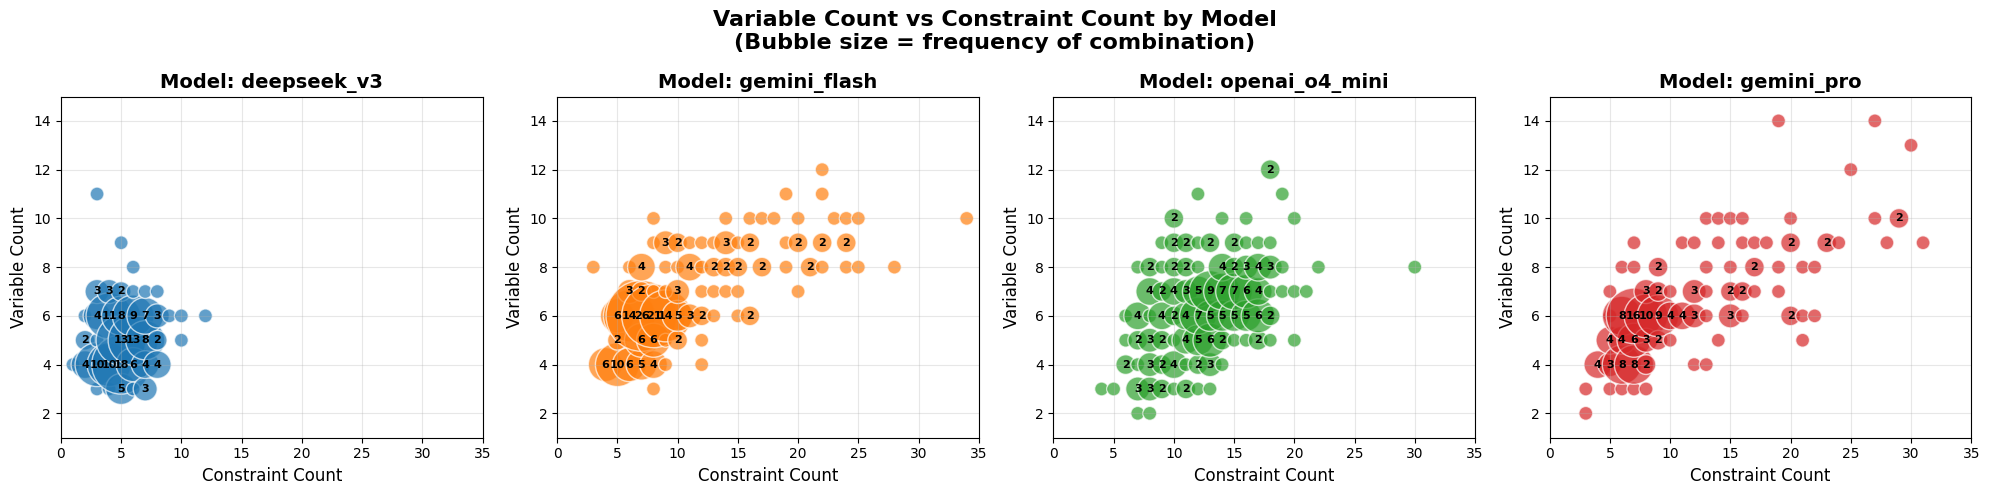

In [4]:
df= pd.read_csv('experiment_results_metrics_corrected_selected.csv')

# Calculate combination frequencies
df_with_counts = df.groupby(['model', 'constraint_count', 'variable_count']).size().reset_index(name='frequency')

# Create the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models = df['model'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Professional color palette

# Get global ranges for consistent scaling
x_range = [df['constraint_count'].min(), df['constraint_count'].max()]
y_range = [df['variable_count'].min(), df['variable_count'].max()]

for i, model in enumerate(models):
    model_data = df_with_counts[df_with_counts['model'] == model]
    
    # Create scatter with bubble sizes
    scatter = axes[i].scatter(
        model_data['constraint_count'],
        model_data['variable_count'],
        s=model_data['frequency'] * 100,  # Bubble size based on frequency
        c=colors[i],
        alpha=0.7,
        edgecolors='white',
        linewidth=1
    )
    
    # Formatting
    axes[i].set_xlim(x_range[0] - 1, x_range[1] + 1)
    axes[i].set_ylim(y_range[0] - 1, y_range[1] + 1)
    axes[i].set_xlabel('Constraint Count', fontsize=12)
    axes[i].set_ylabel('Variable Count', fontsize=12)
    axes[i].set_title(f'Model: {model}', fontsize=14, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    
    # Add frequency as text annotations for clarity
    for _, row in model_data.iterrows():
        if row['frequency'] > 1:  # Only annotate if frequency > 1
            axes[i].annotate(
                str(int(row['frequency'])),
                (row['constraint_count'], row['variable_count']),
                ha='center', va='center',
                fontsize=8, fontweight='bold'
            )

plt.suptitle('Variable Count vs Constraint Count by Model\n(Bubble size = frequency of combination)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [20]:
def create_advanced_scatter_analysis(df, category_col='model', x_col='constraint_count', 
                                      y_col='variable_count',
                                      coherence_col='model_coherence', completeness_col='corrected_completeness',
                                      size_multiplier=30, figsize=None,
                                      show_annotations=True, annotation_threshold=1, 
                                      save_path=None, title_suffix="", 
                                      bottom_margin=0.15, title=False, legend=False):
    """
    Enhanced version with coherence and completeness highlighting.
    Points with coherence=1 and completeness=1 are shown with an inner ring.
    Temperature coloring has been removed - all bubbles use neutral gray color.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    import matplotlib.patches as mpatches
    
    categories = df[category_col].unique()
    n_categories = len(categories)
    
    # Auto-calculate optimal layout
    if n_categories <= 5:
        n_cols, n_rows = n_categories, 1
        default_figsize = (5 * n_categories, 6)
    elif n_categories <= 8:
        n_cols, n_rows = 4, 2
        default_figsize = (20, 12)
    else:
        n_cols = 4
        n_rows = int(np.ceil(n_categories / 4))
        default_figsize = (10, 5 * n_rows + 2)
    
    figsize = figsize or default_figsize
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle different subplot configurations
    if n_categories == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_categories > 1 else [axes]
    else:
        axes = axes.flatten()
    
    # Get global ranges
    x_range = [df[x_col].min(), df[x_col].max()]
    y_range = [df[y_col].min(), df[y_col].max()]
    
    # Track max frequency for size legend
    max_frequency = 0
    
    # Create plots for each category
    for i, category in enumerate(categories):
        category_data = df[df[category_col] == category]
        
        # Aggregate data with coherence and completeness info
        freq_data = category_data.groupby([x_col, y_col]).agg({
            category_col: 'size',
            coherence_col: lambda x: (x == 1).sum() if coherence_col in category_data.columns else 0,
            completeness_col: lambda x: (x == 1).sum() if completeness_col in category_data.columns else 0
        }).reset_index()
        
        freq_data.columns = [x_col, y_col, 'frequency', 
                             'coherence_ones', 'completeness_ones']
        
        # Update max frequency
        max_frequency = max(max_frequency, freq_data['frequency'].max())
        
        # Calculate which points have both coherence=1 and completeness=1
        freq_data['has_perfect'] = np.minimum(freq_data['coherence_ones'], 
                                               freq_data['completeness_ones'])
        
        # First layer: Draw all points (outer bubbles) without edge
        axes[i].scatter(
            freq_data[x_col],
            freq_data[y_col],
            s=freq_data['frequency'] * size_multiplier,
            c='#808080',  # Neutral gray color for all bubbles
            alpha=0.5,  # More transparent for outer layer
            edgecolors='none',  # No edge for outer bubbles
            zorder=1  # Lower z-order for background
        )
        
        # Second layer: Draw inner rings for points with coherence=1 and completeness=1
        perfect_data = freq_data[freq_data['has_perfect'] > 0]
        if not perfect_data.empty:
            # Inner bubble size proportional to the count of perfect scores
            inner_sizes = perfect_data['has_perfect'] * size_multiplier * 0.6  # 60% of outer size
            
            axes[i].scatter(
                perfect_data[x_col],
                perfect_data[y_col],
                s=inner_sizes,
                c='#404040',  # Darker gray for inner ring
                alpha=1,  # More opaque for emphasis
                edgecolors='darkblue',  # Thick dark blue edge
                linewidth=0.5,
                zorder=2  # Higher z-order to appear on top
            )
        
        # Formatting
        axes[i].set_xlim(x_range[0] - 1, x_range[1] + 1)
        axes[i].set_ylim(y_range[0] - 1, y_range[1] + 1)
        axes[i].set_xlabel(x_col.replace('_', ' ').title(), fontsize=12)
        axes[i].set_ylabel(y_col.replace('_', ' ').title(), fontsize=12)
        axes[i].set_title(f'{category_col.title()}: {category}', fontsize=14, fontweight='bold')
        axes[i].grid(True, alpha=0.3, zorder=0)
    
    # Hide unused subplots
    for j in range(n_categories, len(axes)):
        axes[j].set_visible(False)
    
    # Title
    if title:
        main_title = f'{y_col.replace("_", " ").title()} vs {x_col.replace("_", " ").title()} by {category_col.title()}'
        if title_suffix:
            main_title += f' - {title_suffix}'
    
        plt.suptitle(main_title, fontsize=16, fontweight='bold',  x=figsize[0]*0.009)
    
    # Adjust layout with custom spacing for legends at bottom
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])
    
    #legend
    if legend:
        # Create two legend areas at the bottom (removed temperature legend)
        legend_y = 0.08  # Y position for all legends
        
        # 1. Left legend - Bubble size
        size_legend_ax = fig.add_axes([0.15, legend_y - 0.02, 0.30, 0.08], frameon=False)
        size_legend_ax.axis('off')
        
        # Create size legend elements
        sizes = [1, 5, 10, 20] #int(max_frequency)
        size_labels = ['1', '5', '10', '20'] # str(int(max_frequency))
        
        # Position bubbles horizontally
        x_positions = np.linspace(0.2, 0.8, len(sizes))
        for i, (size, label) in enumerate(zip(sizes, size_labels)):
            size_legend_ax.scatter(x_positions[i], 0.5, s=size * size_multiplier, 
                                c='#808080', alpha=0.5, edgecolors='none')
            size_legend_ax.text(x_positions[i], 0.1, label, ha='center', va='top', fontsize=9)
        
        size_legend_ax.text(0.5, 0.9, 'Frequency', ha='center', va='bottom', 
                            fontsize=11, fontweight='bold')
        size_legend_ax.set_xlim(0, 1)
        size_legend_ax.set_ylim(0, 1)
        
        # 2. Right legend - Ring indicators
        ring_legend_ax = fig.add_axes([0.55, legend_y - 0.02, 0.30, 0.08], frameon=False)
        ring_legend_ax.axis('off')
        
        # Create ring legend elements
        # Outer ring only
        ring_legend_ax.scatter(0.25, 0.5, s=150, c='#808080', alpha=0.5, edgecolors='none')
        ring_legend_ax.text(0.25, 0.1, 'All values', ha='center', va='top', fontsize=9)
        
        # Inner + outer ring
        ring_legend_ax.scatter(0.75, 0.5, s=150, c='#808080', alpha=0.5, edgecolors='none')
        ring_legend_ax.scatter(0.75, 0.5, s=90, c='#404040', alpha=1, 
                            edgecolors='darkblue', linewidth=1.5)
        ring_legend_ax.text(0.75, 0.1, 'Accepted (Coherence=1 & Completeness=1)', 
                            ha='center', va='top', fontsize=9)
        
        ring_legend_ax.text(0.5, 0.95, 'MILP acceptance', ha='center', va='bottom', 
                        fontsize=11, fontweight='bold')
        ring_legend_ax.set_xlim(0, 1)
        ring_legend_ax.set_ylim(0, 1)
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, format="pdf", bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    return fig, axes

Plot saved to: C:/Users/joern/GIT/raiLPminer/67531d7506c81a8c34f5794e/figs/scatter_parameter_model.pdf


(<Figure size 1900x400 with 4 Axes>,
 array([<Axes: title={'center': 'Model: deepseek_v3'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Model: gemini_flash'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Model: openai_o4_mini'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Model: gemini_pro'}, xlabel='Constraint Count', ylabel='Variable Count'>],
       dtype=object))

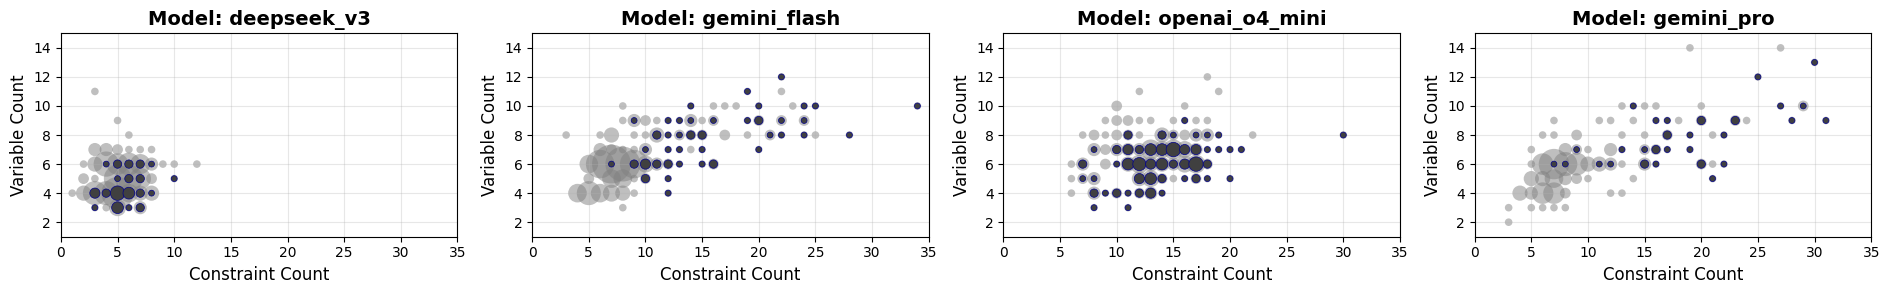

In [23]:
fig_path_dir: str = r"C:/Users/joern/GIT/raiLPminer/67531d7506c81a8c34f5794e/figs/"
create_advanced_scatter_analysis(df[df["paper"] == "Paper_1"], category_col='model',bottom_margin=0.2, figsize=(19, 4), save_path=fig_path_dir+"scatter_parameter_model.pdf") 

Plot saved to: C:/Users/joern/GIT/raiLPminer/67531d7506c81a8c34f5794e/figs/scatter_parameter_workflow.pdf


(<Figure size 1900x400 with 4 Axes>,
 array([<Axes: title={'center': 'Workflow: ZS'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Workflow: CFC'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Workflow: OE'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Workflow: PS'}, xlabel='Constraint Count', ylabel='Variable Count'>],
       dtype=object))

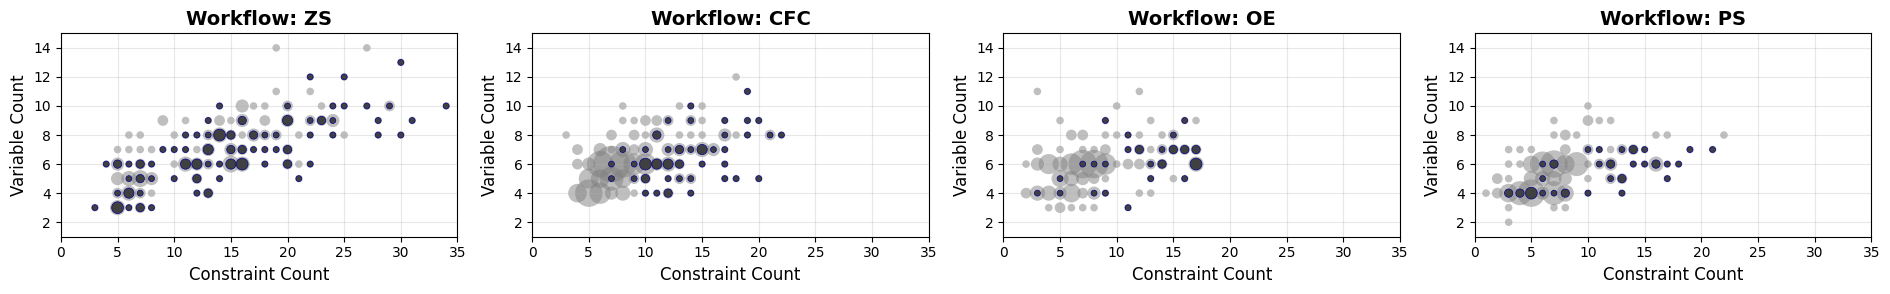

In [30]:
create_advanced_scatter_analysis(df[df["paper"] == "Paper_1"], category_col='workflow',bottom_margin=0.2, figsize=(19, 4), save_path=fig_path_dir+"scatter_parameter_workflow.pdf")

Plot saved to: C:/Users/joern/GIT/raiLPminer/67531d7506c81a8c34f5794e/figs/scatter_parameter_temp.pdf


(<Figure size 1425x400 with 5 Axes>,
 array([<Axes: title={'center': 'Temperature: 0.2'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Temperature: 0.6'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Temperature: 1.0'}, xlabel='Constraint Count', ylabel='Variable Count'>],
       dtype=object))

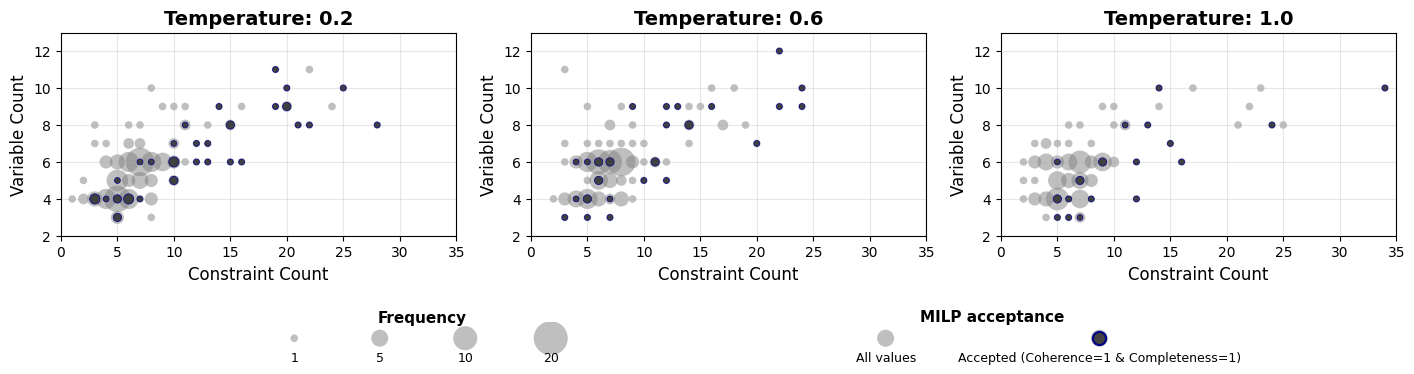

In [29]:
create_advanced_scatter_analysis(df[(df["paper"] == "Paper_1") & ~(df['model'].str.contains('openai_o4_mini', na=False))& ~(df['model'].str.contains('pro', na=False))], category_col='temperature',bottom_margin=0.2, figsize=(19/4*3, 4), save_path=fig_path_dir+"scatter_parameter_temp.pdf", legend=True)

(<Figure size 2000x400 with 7 Axes>,
 array([<Axes: title={'center': 'Paper: Paper_1'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Paper: Paper_2'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Paper: Paper_3'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Paper: Paper_4'}, xlabel='Constraint Count', ylabel='Variable Count'>,
        <Axes: title={'center': 'Paper: Paper_5'}, xlabel='Constraint Count', ylabel='Variable Count'>],
       dtype=object))

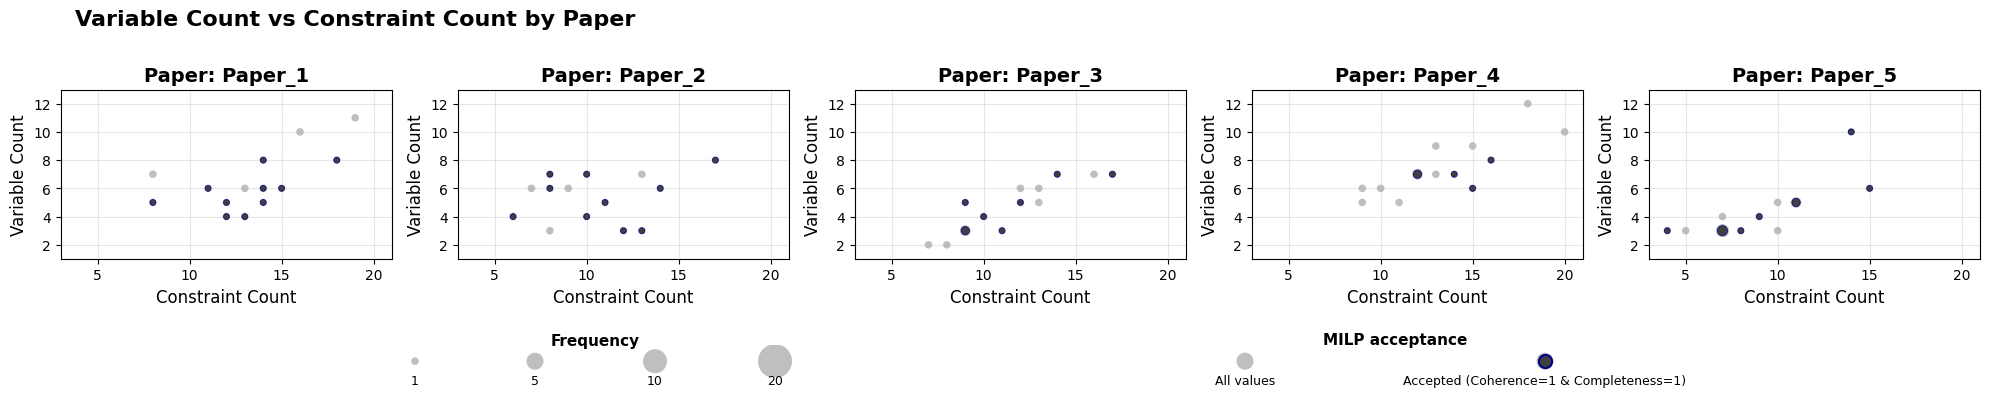

In [9]:

'''
create_advanced_scatter_analysis(
    df[(df["model"] == "openai_o4_mini") & (df["workflow"] == "ZS")& (df["temperature"] == 1)], 
    category_col='paper', 
    bottom_margin=0.2
)
'''

#create_advanced_scatter_analysis(df[df["paper"] == "Paper_1"], category_col='temperature',bottom_margin=0.2, figsize=(15, 4)) 
create_advanced_scatter_analysis(df[(df['temperature'] == 1.0) & (df['workflow'].str.contains('ZS', na=False)) & (df['model'].str.contains('openai_o4_mini', na=False))]
, category_col='paper',bottom_margin=0.2, figsize=(20, 4)) 

## Runtime Analysis

In [ ]:
df=df_processed

def plot_runtime_boxplots(df, categories=["model", "temperature", "workflow", "paper"], figsize=(10, 8)):
    """
    Plots horizontal boxplots of runtime for given categorical columns in one graph.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must contain 'runtime' and the categorical columns.
    categories : list of str
        Column names to group by.
    figsize : tuple
        Size of the figure (width, height).
    """
    plt.figure(figsize=figsize)

    positions = []
    data = []
    labels = []
    offset = 0
    gap = 2  # spacing between category groups
    width = 0.6

    for cat in categories:
        groups = df[cat].unique()
        for i, g in enumerate(groups):
            runtimes = df.loc[df[cat] == g, "runtime"]
            data.append(runtimes)
            positions.append(offset + i)
            labels.append(f"{cat}: {g}")
        offset += len(groups) + gap

    # Horizontal boxplot
    plt.boxplot(data, positions=positions, widths=width, vert=False)

    plt.yticks(positions, labels)
    plt.xlabel("Runtime [s]")
    plt.title("Runtime Distribution by Setup")
    plt.tight_layout()
    plt.show()


In [ ]:
df_filtered=df[(df['temperature'] == 1.0) & (df['workflow'].str.contains('ZS', na=False)) & (df['model'].str.contains('openai_o4_mini', na=False))]
plot_runtime_boxplots(df_filtered, categories=["paper"] ,figsize=(20,4))

In [ ]:
df_filtered=df[(df['paper'] == 'Paper_1')]
plot_runtime_boxplots(df_filtered, categories=["model", "temperature", "workflow",], figsize=(20,8))

In [ ]:
df_filtered=df
plot_runtime_boxplots(df_filtered, categories=["model_completeness", "model_coherence"], figsize=(20,8))